In [53]:
from builtins import print
import pandas as pd

print("hello world")

hello world


In [24]:
import pandas as pd

df_base = pd.read_excel('BASE_NEUROCOVID_FINALE_copy.xls')
print(df_base.head())

          IPP   N_PAT  SEXE        DDN  AGE  HTA  Diabète  Obésité   IMC  \
0  8005010327  8064.0     2 1969-12-31   50    0        0        1  34.5   
1  8013688574  8058.0     1 1956-09-06   64    1        0        0  23.0   
2  8001480966  8067.0     2 1954-02-12   66    1        1        0   NaN   
3  8004769613  8063.0     1 1959-08-31   61    1        0        1  32.5   
4  8004987536  8094.0     1 1949-10-07   70    1        1        1   NaN   

   BPCO /Iresp  ...  ECMO  Date ECMO  IRA.1 HDI           Date décès  \
0            0  ...     0        NaT      0   0                    0   
1            0  ...     0        NaT      0   0                    0   
2            0  ...     0        NaT      0   0                    0   
3            0  ...     0        NaT      1   0                    0   
4            0  ...     0        NaT      0   0  2020-09-21 00:00:00   

   Mortalité J28  Mortalité globale  Durée séjour réa  Durée S Hospi  \
0              1                  1   

In [55]:
ids = df_base[(df_base['Mortalité J28'] == 1) & (df_base['Mortalité globale'] == 0)]['N_PAT'].tolist()
print(ids)


[8347.0, nan]


In [56]:
import matplotlib.pyplot as plt


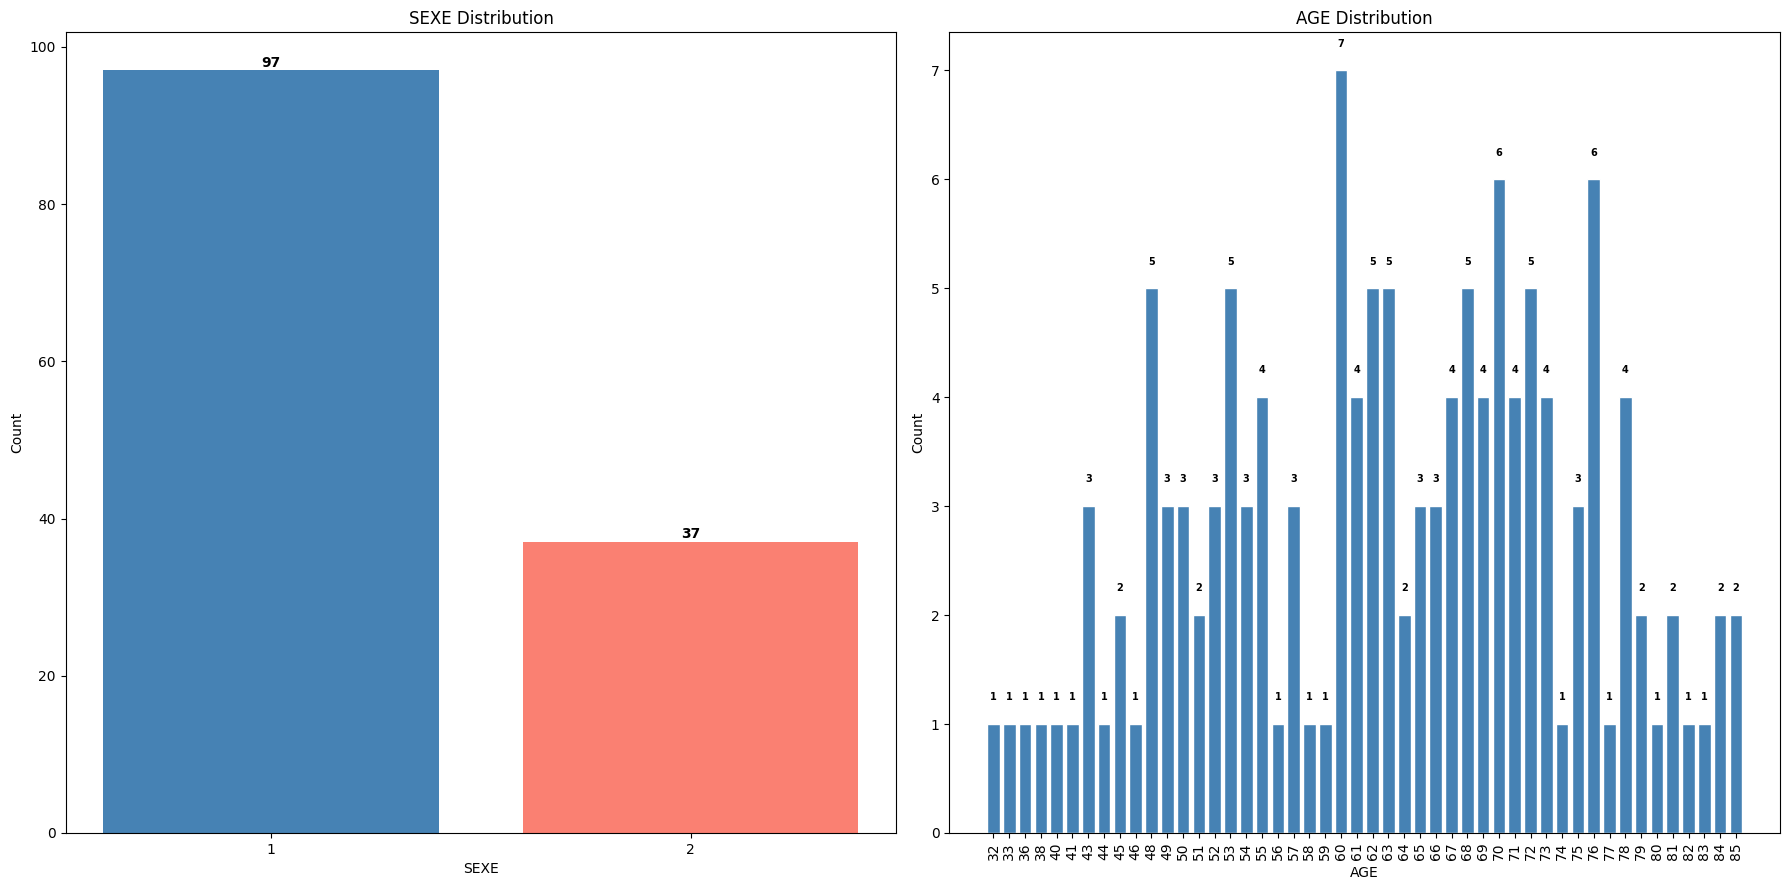

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

sexe_counts = df['SEXE'].value_counts()
ax1.bar(sexe_counts.index.astype(str), sexe_counts.values, color=['steelblue', 'salmon'])
ax1.set_title('SEXE Distribution')
ax1.set_xlabel('SEXE')
ax1.set_ylabel('Count')
for i, v in enumerate(sexe_counts.values):
    ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

age_counts = df['AGE'].dropna().astype(int).value_counts().sort_index()
bars = ax2.bar(age_counts.index.astype(str), age_counts.values, color='steelblue', edgecolor='white')
ax2.set_title('AGE Distribution')
ax2.set_xlabel('AGE')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=90)

for bar, v in zip(bars, age_counts.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             str(v), ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

In [58]:
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().sum() / len(df) * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print(f"Total rows: {len(df)}\n")
print(missing.to_string())

Total rows: 134

                                                                   Missing Count  Missing %
Valeur NSE 7 (µg/l)                                                          134     100.00
Date NSE 6                                                                   134     100.00
Valeur NSE 6                                                                 134     100.00
Date NSE 7                                                                   134     100.00
Date EEG 4                                                                   133      99.25
Date EEG 3                                                                   133      99.25
Val Pup 2 OD                                                                 130      97.01
Valeur PS100 6     (µg/l)                                                    130      97.01
Date PS100 6                                                                 130      97.01
Val Pup 2 OG                                                   

In [59]:
folder = r'C:\abalaji\bichat\ORIGINAL_DATA'
import os

file_names = os.listdir(folder)

valid_ids = set()
for f in file_names:
    name = os.path.splitext(f)[0]
    try:
        valid_ids.add(int(name))
    except ValueError:
        pass

print(f"Found {len(valid_ids)} valid file IDs")

df_filtered = df[df['N_PAT'].isin(valid_ids)].copy()

print(f"Original rows: {len(df)}")
print(f"Kept rows:     {len(df_filtered)}")
print(f"Dropped rows:  {len(df) - len(df_filtered)}")

df_filtered.to_excel('filtered.xlsx', index=False)

Found 98 valid file IDs
Original rows: 134
Kept rows:     98
Dropped rows:  36


In [60]:
df_filtered = pd.read_excel('filtered.xlsx')
print(df_filtered.shape)
print(df_filtered.head())

(98, 97)
          IPP  N_PAT  SEXE        DDN  AGE  HTA  Diabète  Obésité   IMC  \
0  8005010327   8064     2 1969-12-31   50    0        0        1  34.5   
1  8013688574   8058     1 1956-09-06   64    1        0        0  23.0   
2  8001480966   8067     2 1954-02-12   66    1        1        0   NaN   
3  8004769613   8063     1 1959-08-31   61    1        0        1  32.5   
4  8004987536   8094     1 1949-10-07   70    1        1        1   NaN   

   BPCO /Iresp  ...  ECMO  Date ECMO  IRA.1 HDI           Date décès  \
0            0  ...     0        NaT      0   0                    0   
1            0  ...     0        NaT      0   0                    0   
2            0  ...     0        NaT      0   0                    0   
3            0  ...     0        NaT      1   0                    0   
4            0  ...     0        NaT      0   0  2020-09-21 00:00:00   

   Mortalité J28  Mortalité globale  Durée séjour réa  Durée S Hospi  \
0              1                  1

In [61]:
missing = pd.DataFrame({
    'Missing Count': df_filtered.isna().sum(),
    'Missing %': (df_filtered.isna().sum() / len(df_filtered) * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print(f"Total rows: {len(df_filtered)}\n")
print(missing.to_string())

Total rows: 98

                           Missing Count  Missing %
Valeur NSE 7 (µg/l)                   98     100.00
Date NSE 6                            98     100.00
Valeur NSE 6                          98     100.00
Date NSE 7                            98     100.00
Durée ECMO                            97      98.98
Date ECMO                             97      98.98
Date EEG 4                            97      98.98
Date EEG 3                            97      98.98
Val Pup 2 OD                          95      96.94
Valeur PS100 6     (µg/l)             94      95.92
Date PS100 6                          94      95.92
Date Pup 2                            94      95.92
Val Pup 2 OG                          94      95.92
Date EEG 2                            93      94.90
DATE NSE 5                            88      89.80
Valeur NSE 5 (µg/L)                   88      89.80
Valeur PS 100 5  (µg/l)               86      87.76
Date PS100 5                          86      87

In [62]:
missing_in_df = valid_ids - set(df_filtered['N_PAT'])

print(f"Missing in df_filtered: {len(missing_in_df)}")
print(sorted(missing_in_df))

Missing in df_filtered: 0
[]


In [63]:
cols_to_drop = missing.index.tolist()
df_clean = df_filtered.drop(columns=cols_to_drop)

print(f"\nDropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Remaining columns: {df_clean.shape[1]}")
print(df_clean.columns.tolist())


Dropped 42 columns: ['Valeur NSE 7 (µg/l)', 'Date NSE 6', 'Valeur NSE 6', 'Date NSE 7', 'Durée ECMO', 'Date ECMO', 'Date EEG 4', 'Date EEG 3', 'Val Pup 2 OD', 'Valeur PS100 6     (µg/l)', 'Date PS100 6 ', 'Date Pup 2', 'Val Pup 2 OG', 'Date EEG 2', 'DATE NSE 5', 'Valeur NSE 5 (µg/L)', 'Valeur PS 100 5  (µg/l)', 'Date PS100 5', 'Date VM', 'DATE NSE 4', 'Valeur NSE 4 (µg/L)', 'Valeur PS100 4 (µg/l)', 'Date PS 100 4 ', 'Valeur pup 1 OD', 'VALEUR NSE 3 (µg/L)', 'DATE NSE 3', 'Valeur PS100 3 (µg/l)', 'Date PS100 3', 'Valeur puillo 1 OG (%)', 'Date pup 1', 'DATE NSE 2 ', 'Valeur NSE 2 (µg/L)', 'Date PS100 2', 'Valeur PS 100 2 (µg/l)', 'Valeur NSE 1 (µg/L)', 'DATE NSE 1', 'P/F min', 'P/F initial', 'IMC', 'Valeur PS 100 1 (µg/l)', 'Date PS100 1', 'Co mribidités']
Remaining columns: 55
['IPP', 'N_PAT', 'SEXE', 'DDN', 'AGE', 'HTA', 'Diabète', 'Obésité', 'BPCO /Iresp', 'IC', 'IRC', 'Cirrhose', 'ImmunoD', 'Neuro', 'Confusion / RPM', 'GCS', 'Hyperthermie entrée', 'Anosmie /agueusie', 'Céphalées', 

In [64]:
print(df_clean.head())


          IPP  N_PAT  SEXE        DDN  AGE  HTA  Diabète  Obésité  \
0  8005010327   8064     2 1969-12-31   50    0        0        1   
1  8013688574   8058     1 1956-09-06   64    1        0        0   
2  8001480966   8067     2 1954-02-12   66    1        1        0   
3  8004769613   8063     1 1959-08-31   61    1        0        1   
4  8004987536   8094     1 1949-10-07   70    1        1        1   

   BPCO /Iresp  IC  ...  VM  Durée VM (jours)  ECMO  IRA.1  HDI  \
0            0   0  ...   1                 1     0      0    0   
1            0   0  ...   0                 0     0      0    0   
2            0   0  ...   0                 0     0      0    0   
3            0   0  ...   0                 0     0      1    0   
4            0   0  ...   0                 0     0      0    0   

            Date décès  Mortalité J28  Mortalité globale  Durée séjour réa  \
0                    0              1                  1                 8   
1                    0    

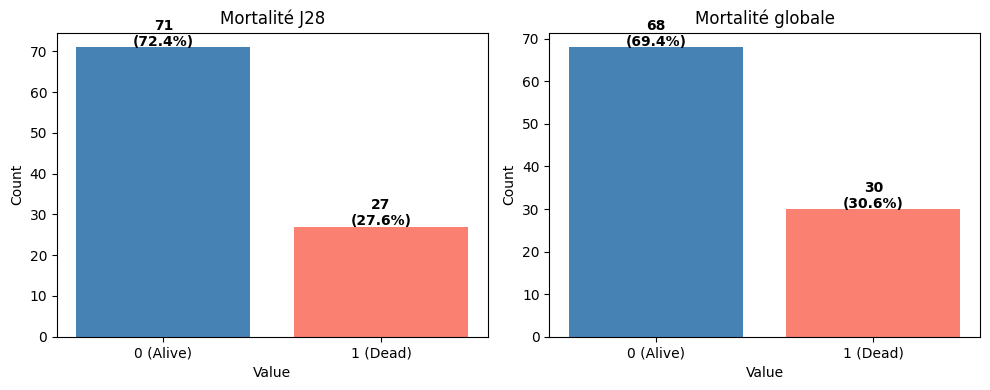

In [65]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ['Mortalité J28', 'Mortalité globale']):
    counts = df_clean[col].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values, color=['steelblue', 'salmon'])
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0 (Alive)', '1 (Dead)'])
    for bar, v in zip(bars, counts.values):
        pct = round(v / len(df_clean) * 100, 1)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v}\n({pct}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('mortality.png', dpi=150)
plt.show()

In [66]:
df_clean['Mortalité J60'] = (
    (df_clean['Mortalité J28'] == 0) & (df_clean['Mortalité globale'] == 1)
).astype(int)

print(df_clean['Mortalité J60'].value_counts().sort_index())

Mortalité J60
0    94
1     4
Name: count, dtype: int64


In [67]:
print(df_clean.loc[df_clean['Mortalité J60'] == 1, 'N_PAT'].tolist())

[8243, 8257, 8268, 8469]


In [68]:
print(df_clean.head())

          IPP  N_PAT  SEXE        DDN  AGE  HTA  Diabète  Obésité  \
0  8005010327   8064     2 1969-12-31   50    0        0        1   
1  8013688574   8058     1 1956-09-06   64    1        0        0   
2  8001480966   8067     2 1954-02-12   66    1        1        0   
3  8004769613   8063     1 1959-08-31   61    1        0        1   
4  8004987536   8094     1 1949-10-07   70    1        1        1   

   BPCO /Iresp  IC  ...  Durée VM (jours)  ECMO  IRA.1  HDI  \
0            0   0  ...                 1     0      0    0   
1            0   0  ...                 0     0      0    0   
2            0   0  ...                 0     0      0    0   
3            0   0  ...                 0     0      1    0   
4            0   0  ...                 0     0      0    0   

            Date décès  Mortalité J28  Mortalité globale  Durée séjour réa  \
0                    0              1                  1                 8   
1                    0              0             

In [69]:
df_base = pd.read_excel('BASE_NEUROCOVID_FINALE_copy.xls')
print(df_base.head())

          IPP   N_PAT  SEXE        DDN  AGE  HTA  Diabète  Obésité   IMC  \
0  8005010327  8064.0     2 1969-12-31   50    0        0        1  34.5   
1  8013688574  8058.0     1 1956-09-06   64    1        0        0  23.0   
2  8001480966  8067.0     2 1954-02-12   66    1        1        0   NaN   
3  8004769613  8063.0     1 1959-08-31   61    1        0        1  32.5   
4  8004987536  8094.0     1 1949-10-07   70    1        1        1   NaN   

   BPCO /Iresp  ...  ECMO  Date ECMO  IRA.1 HDI           Date décès  \
0            0  ...     0        NaT      0   0                    0   
1            0  ...     0        NaT      0   0                    0   
2            0  ...     0        NaT      0   0                    0   
3            0  ...     0        NaT      1   0                    0   
4            0  ...     0        NaT      0   0  2020-09-21 00:00:00   

   Mortalité J28  Mortalité globale  Durée séjour réa  Durée S Hospi  \
0              1                  1   

In [70]:
ids = df_clean.loc[df_clean['Mortalité J60'] == 1, 'N_PAT'].tolist()

subset = df_base[df_base['N_PAT'].isin(ids)][['N_PAT', 'Date admission réa', 'Date décès']]
print(subset.to_string(index=False))

 N_PAT Date admission réa          Date décès
8243.0         2020-10-18 2020-11-28 00:00:00
8257.0         2020-10-19 2020-12-04 00:00:00
8268.0         2020-10-23 2021-12-06 00:00:00
8469.0         2020-12-13 2022-03-05 00:00:00


In [71]:
print(df_base.columns.tolist())



['IPP', 'N_PAT', 'SEXE', 'DDN', 'AGE', 'HTA', 'Diabète', 'Obésité', 'IMC', 'BPCO /Iresp', 'IC', 'IRC', 'Cirrhose', 'Co mribidités', 'ImmunoD', 'Neuro', 'Confusion / RPM', 'GCS', 'Hyperthermie entrée', 'Anosmie /agueusie', 'Céphalées', 'IRA', 'Signes digestifs', 'IGS II', 'SF1', 'P/F initial', 'P/F min', 'Date admission réa', 'Date sortie réa ', 'Date EEG 1', 'Date EEG 2', 'Date EEG 3', 'Date EEG 4', 'EEG reactif stimuli SA et SN (oui 1, non 0, ne se prononce pas 3)', 'Réactivité  Auditive (oui1 non 0)', 'Reactivité Nociceptive (oui1 non 0)', 'EEG activité de fond (continue 0 discontinue 1)', 'Suppression Burst (oui 1 non 0)', 'Rythme de fond Min (C/S)', 'Rythme de fond Max (c/s)', 'EEG Asymétrie (oui 1 non 0)', 'Tracé plat (oui 1 non 0)', 'EEG figures épileptiques (aucune 0 généralisées 1 Focales 2)', 'Figures du sommeil (oui 1 non 0)', 'Complexes K (oui1 non 0)', 'Fuseaux de sommeil (oui 1 non 0)', 'Complexes Lents périodiques (oui 1 non 0)', 'CL périodiques (non 0, focaux 1 généralis

In [72]:
df_clean.to_excel('filtered.xlsx', index=False)


In [74]:
ids = df_clean[(df_clean['Mortalité J28'] == 1) & (df_clean['Mortalité globale'] == 0)]['N_PAT'].tolist()
print(ids)


[8347]


In [75]:
df_clean = df_clean[~((df_clean['Mortalité J28'] == 0) & (df_clean['Mortalité globale'] == 1))]
print(f"Remaining rows: {len(df_clean)}")

Remaining rows: 94


In [76]:
df_clean.to_excel('filtered.xlsx', index=False)


In [78]:
print(f"Remaining rows: {len(df_clean)}")


Remaining rows: 94


In [83]:
import os

folder = r'C:\abalaji\bichat\ORIGINAL_DATA'
file_ids = set()
for f in os.listdir(folder):
    name = os.path.splitext(f)[0]
    try:
        file_ids.add(int(name))
    except ValueError:
        pass

df_clean_ids = set(df_clean['N_PAT'])
df_base_ids = set(df_base['N_PAT'])

print(f"Files in folder:      {len(file_ids)}")
print(f"Patients in df_clean: {len(df_clean_ids)}")
print(f"Patients in df_base:  {len(df_base_ids)}")

print(f"\n--- df_clean ---")
print(f"In folder but NOT in df_clean: {sorted(file_ids - df_clean_ids)}")
print(f"In df_clean but NOT in folder: {sorted(df_clean_ids - file_ids)}")

print(f"\n--- df_base ---")
print(f"In folder but NOT in df_base:  {sorted(file_ids - df_base_ids)}")
print(f"In df_base but NOT in folder:  {sorted(df_base_ids - file_ids)}")

Files in folder:      97
Patients in df_clean: 98
Patients in df_base:  134

--- df_clean ---
In folder but NOT in df_clean: []
In df_clean but NOT in folder: [8347.0]

--- df_base ---
In folder but NOT in df_base:  []
In df_base but NOT in folder:  [nan, nan, nan, 8581.0, nan, nan, nan, nan, nan, nan, nan, 8347.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 5039.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [82]:
missing_ids = file_ids - df_clean_ids
missing_rows = df_base[df_base['N_PAT'].isin(missing_ids)]
missing_rows = missing_rows[[col for col in df_clean.columns if col in missing_rows.columns]]
df_clean = pd.concat([df_clean, missing_rows], ignore_index=True)

print(f"Added {len(missing_rows)} rows")
print(f"df_clean now has {len(df_clean)} rows")

Added 4 rows
df_clean now has 98 rows


In [84]:
df_clean = df_clean[df_clean['N_PAT'] != 8347]
print(f"Remaining rows: {len(df_clean)}")

Remaining rows: 97


In [3]:
df_clean.to_excel('filtered.xlsx', index=False)


NameError: name 'df_clean' is not defined

In [4]:
df_clean = pd.read_excel('filtered.xlsx')
print(df_clean.shape)
print(df_clean.head())

(97, 56)
          IPP  N_PAT  SEXE        DDN  AGE  HTA  Diabète  Obésité  \
0  8005010327   8064     2 1969-12-31   50    0        0        1   
1  8013688574   8058     1 1956-09-06   64    1        0        0   
2  8001480966   8067     2 1954-02-12   66    1        1        0   
3  8004769613   8063     1 1959-08-31   61    1        0        1   
4  8004987536   8094     1 1949-10-07   70    1        1        1   

   BPCO /Iresp  IC  ...  Durée VM (jours)  ECMO  IRA.1  HDI  \
0            0   0  ...                 1     0      0    0   
1            0   0  ...                 0     0      0    0   
2            0   0  ...                 0     0      0    0   
3            0   0  ...                 0     0      1    0   
4            0   0  ...                 0     0      0    0   

            Date décès  Mortalité J28  Mortalité globale  Durée séjour réa  \
0                    0              1                  1                 8   
1                    0              0    

In [26]:
import pandas as pd
import numpy as np

rows = []
with open(r'/ORIGINAL_DATA/1214', 'r') as f:
    for line in f:
        parts = line.strip().split()
        if not parts:
            continue
        if ':' in parts[0]:
            parts = parts[1:]
        if len(parts) == 19:
            rows.append(parts)

col_names = ['Fp1','C3','P3','O1','F7','T3','T5','Cz','Pz',
             'Fp2','C4','P4','O2','F8','T4','T6','ECG','BLANK','MKR']

df = pd.DataFrame(rows, columns=col_names)
df = df.iloc[5:].reset_index(drop=True)
df = df.apply(pd.to_numeric, errors='coerce')

eeg_df = df[['Fp1','C3','P3','O1','F7','T3','T5','Cz',
             'Pz','Fp2','C4','P4','O2','F8','T4','T6','ECG']].copy()

sfreq = 256
n_samples = len(eeg_df)
eeg_df.insert(0, 'time', np.arange(n_samples) / sfreq)

print(eeg_df.shape)
print(eeg_df.head(-10))

(307320, 18)
               time     Fp1      C3      P3      O1      F7      T3      T5  \
0          0.000000  -73.72 -208.72  103.83   21.85   82.02   -0.85   41.38   
1          0.003906  296.92   47.44  453.64  277.31  338.29  348.85  330.35   
2          0.007812  585.06  254.21  758.54  502.47  600.60  636.51  607.24   
3          0.011719  395.56   85.80  643.66  414.21  529.83  485.73  512.56   
4          0.015625  219.41  -61.50  480.32  289.99  391.68  313.98  362.19   
...             ...     ...     ...     ...     ...     ...     ...     ...   
307305  1200.410156   73.93   56.01   32.13   29.01   27.62   47.35   51.44   
307306  1200.414062   65.54   42.27   23.84   19.06   35.71   45.71   50.74   
307307  1200.417969   62.80   45.71   21.12   29.68   52.46   43.06   59.64   
307308  1200.421875   70.23   41.86   27.12   10.17    9.83   37.81   42.06   
307309  1200.425781   58.85   31.24   13.92   17.61   51.51   37.05   50.90   

            Cz      Pz     Fp2      C4

In [96]:
eeg_df.to_csv(r'C:\abalaji\bichat\eeg_csv\1214.csv', index=False)

print(f"Saved! Shape: {eeg_df.shape}")
print(eeg_df.head())

Saved! Shape: (307320, 18)
       time     Fp1      C3      P3      O1      F7      T3      T5      Cz  \
0  0.000000  -73.72 -208.72  103.83   21.85   82.02   -0.85   41.38 -122.31   
1  0.003906  296.92   47.44  453.64  277.31  338.29  348.85  330.35  215.56   
2  0.007812  585.06  254.21  758.54  502.47  600.60  636.51  607.24  500.26   
3  0.011719  395.56   85.80  643.66  414.21  529.83  485.73  512.56  318.25   
4  0.015625  219.41  -61.50  480.32  289.99  391.68  313.98  362.19  147.16   

       Pz     Fp2      C4      P4      O2      F8      T4      T6     ECG  
0 -122.12 -648.22   89.22   41.96   16.22 -196.20   86.77  103.28 -249.72  
1  210.37 -488.05  300.17  345.27  308.51   47.11  411.12  267.01 -386.36  
2  467.75 -395.75  508.73  630.40  586.12  225.82  676.82  488.26  -26.77  
3  276.73 -655.00  454.80  521.55  484.27   47.77  547.44  472.55  254.68  
4  105.71 -787.59  350.31  366.37  338.71  -82.21  403.71  370.24  265.98  


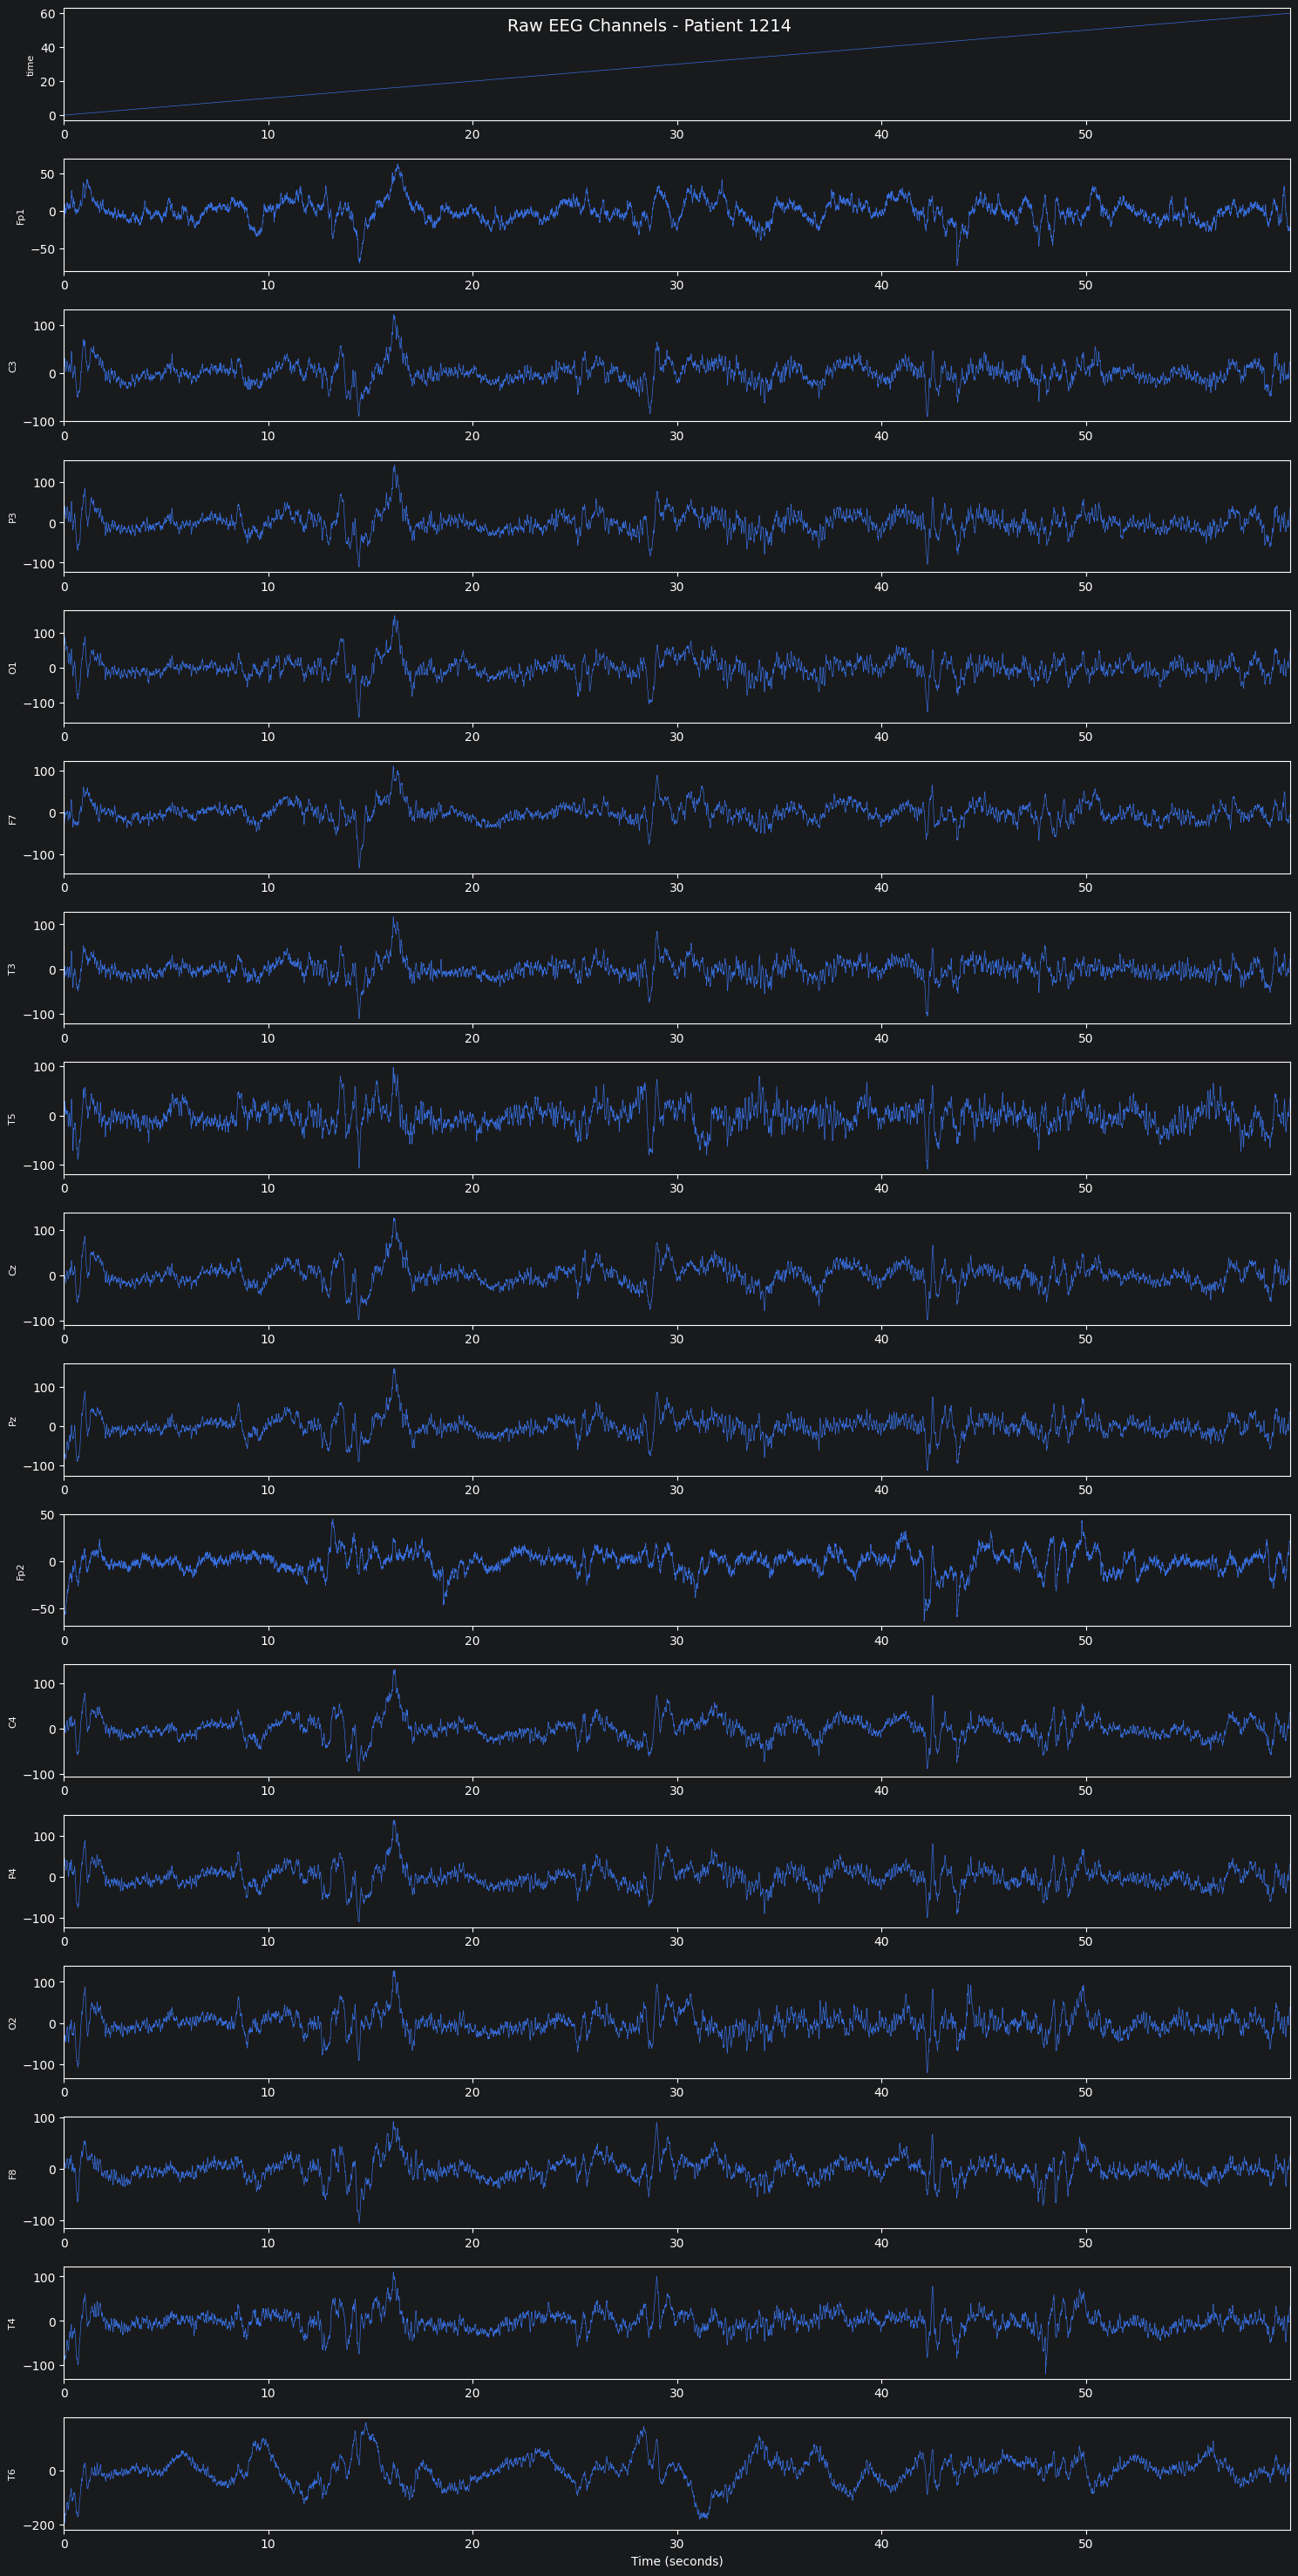

In [25]:
fig, axes = plt.subplots(17, 1, figsize=(15, 30))

for i, ch in enumerate(ch_names):
    axes[i].plot(eeg_df['time'], eeg_df[ch], linewidth=0.5)
    axes[i].set_ylabel(ch, fontsize=8)
    axes[i].set_xlim(eeg_df['time'].min(), eeg_df['time'].max())

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle('Raw EEG Channels - Patient 1214', fontsize=14)
plt.tight_layout()
plt.savefig('eegplot.png', dpi=150)

plt.show()

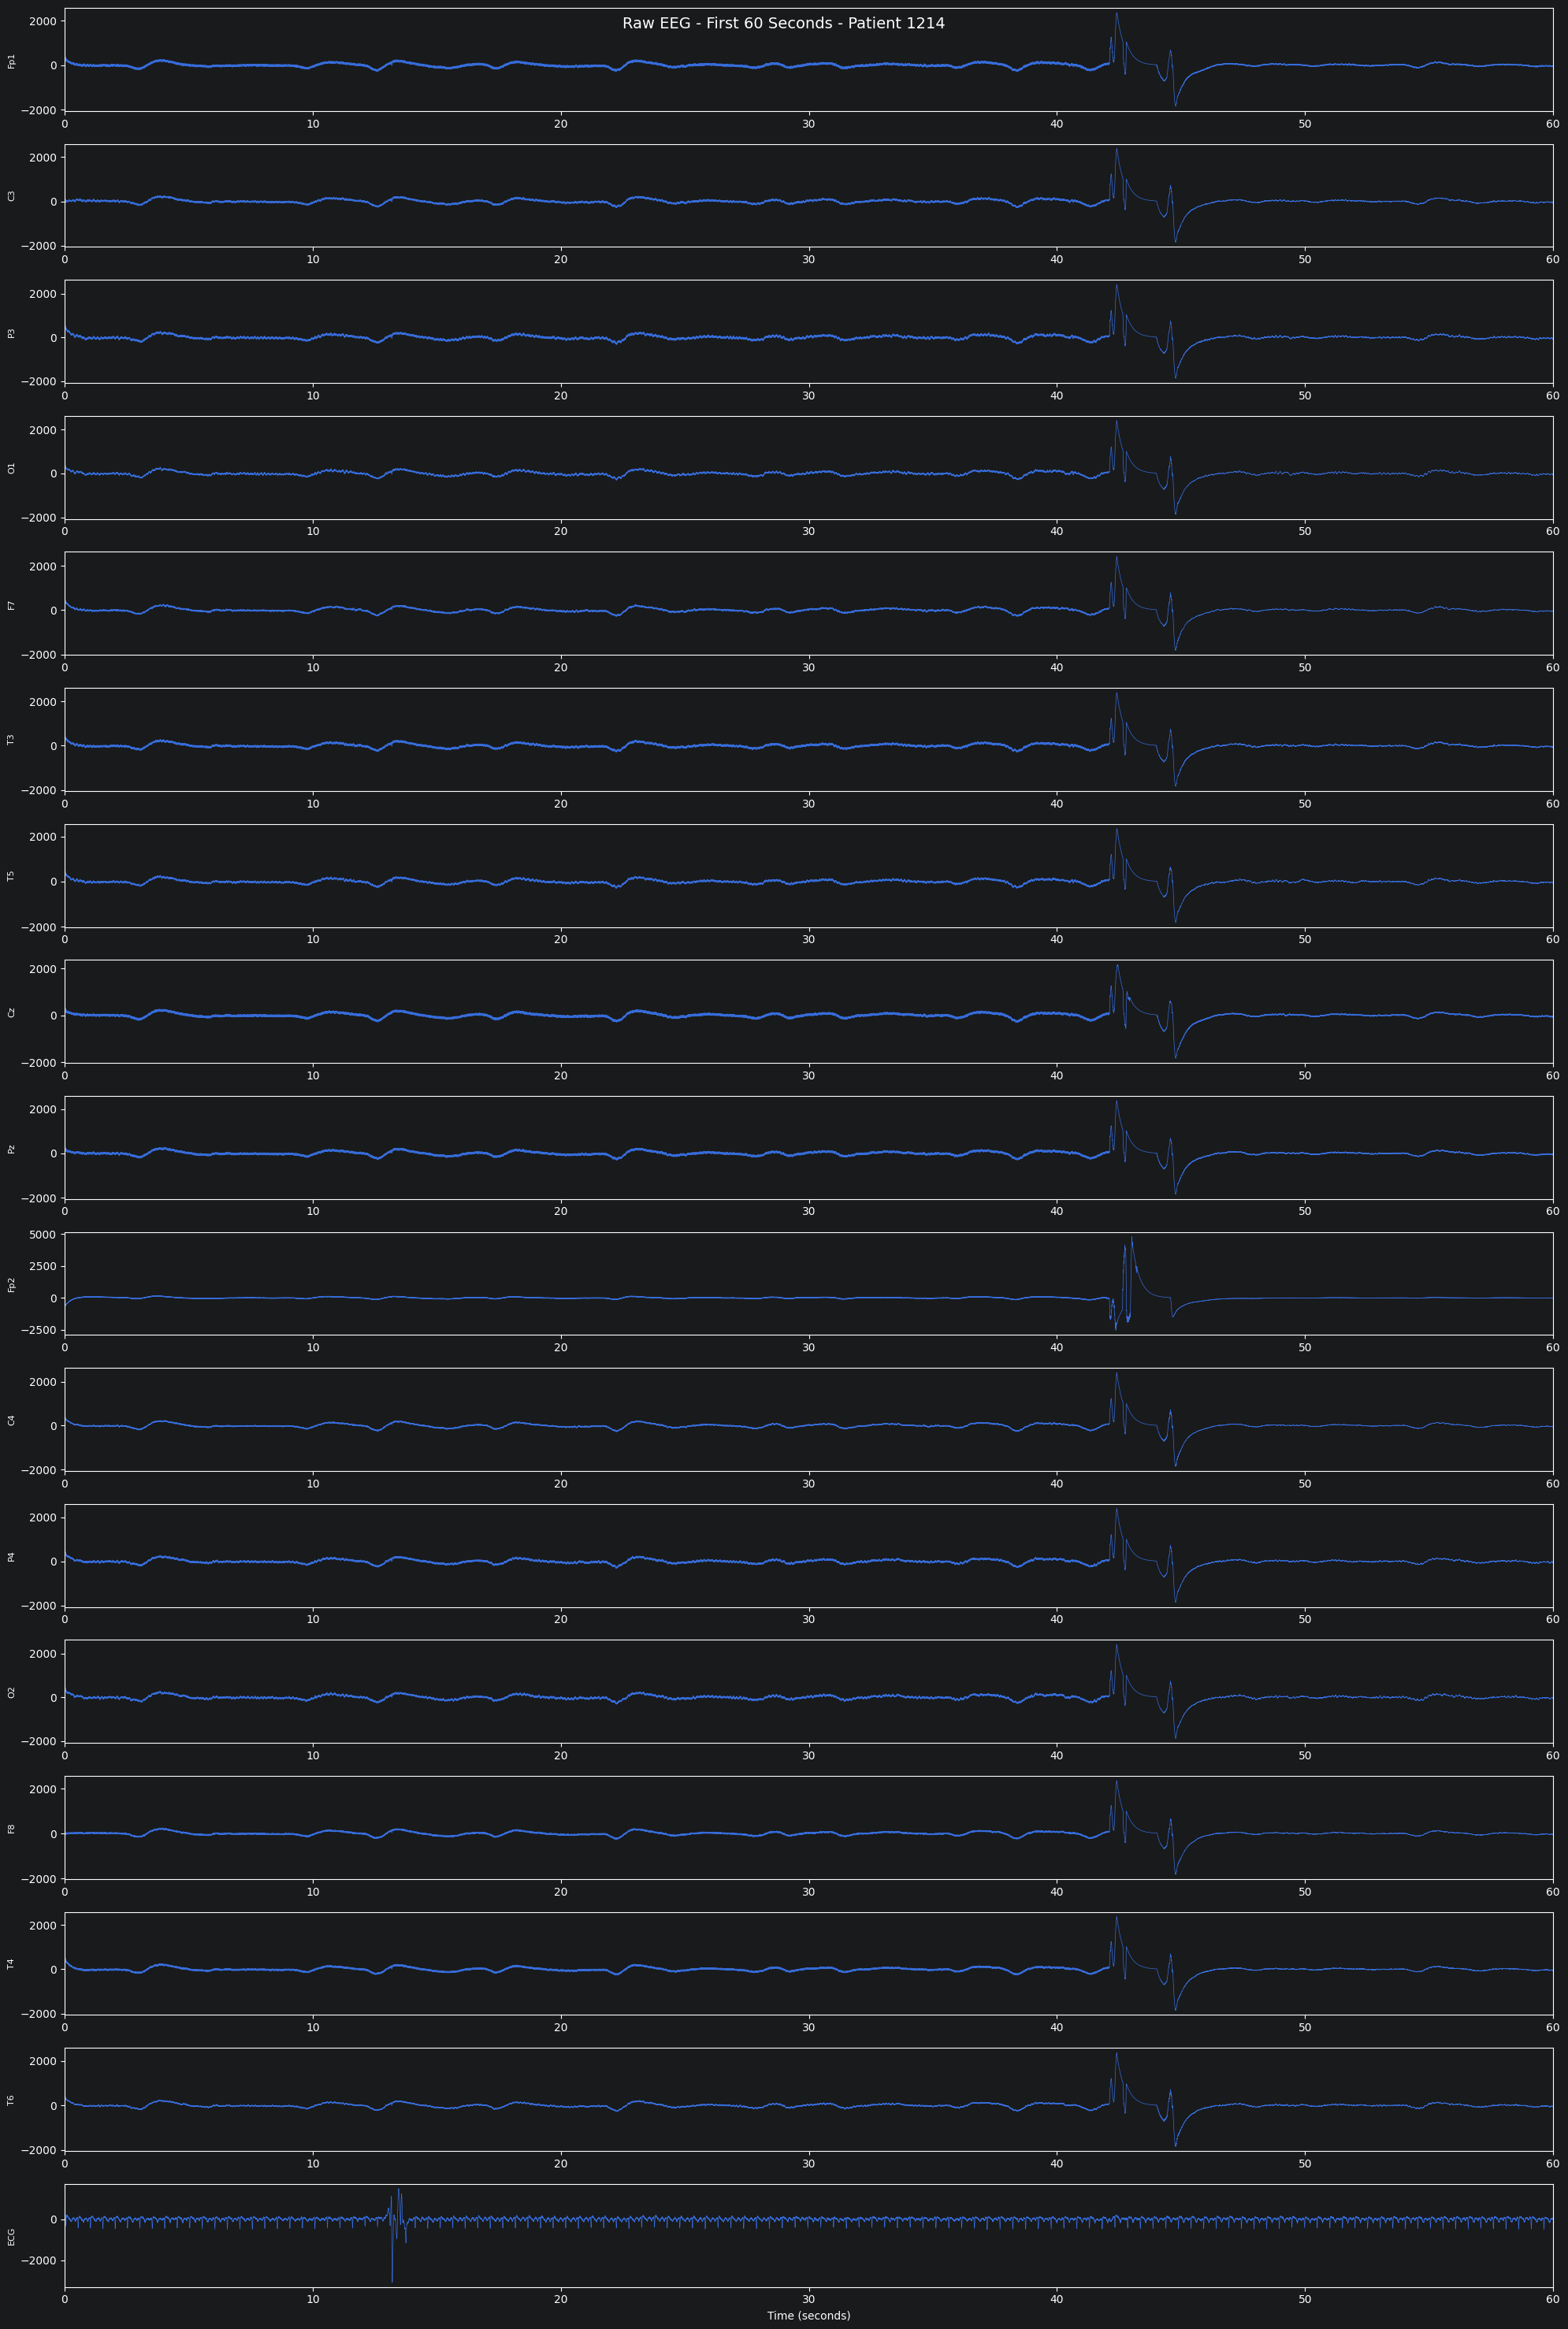

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

eeg_df = pd.read_csv(r'C:\abalaji\bichat\eeg_csv\1214.csv')

ch_names = ['Fp1','C3','P3','O1','F7','T3','T5','Cz',
            'Pz','Fp2','C4','P4','O2','F8','T4','T6','ECG']

# First 60 seconds
window = eeg_df[eeg_df['time'] <= 60.0]

fig, axes = plt.subplots(17, 1, figsize=(20, 30))

for i, ch in enumerate(ch_names):
    axes[i].plot(window['time'], window[ch], linewidth=0.5)
    axes[i].set_ylabel(ch, fontsize=8)
    axes[i].set_xlim(0, 60)

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle('Raw EEG - First 60 Seconds - Patient 1214', fontsize=14)
plt.tight_layout()
plt.savefig('eegplot_60.png', dpi=150)

plt.show()

In [27]:
ids = df_clean.loc[df_clean['Mortalité J28'] == 1, 'N_PAT'].tolist()
print(ids)

[8064, 8094, 8093, 8104, 8128, 8154, 8174, 8194, 8192, 8204, 8217, 8228, 8227, 8250, 8275, 8279, 8280, 8286, 8290, 8298, 8300, 8342, 5160, 8635, 8759, 8816]


In [12]:
import pandas as pd
import numpy as np
import os

input_folder = r'C:\abalaji\bichat\ORIGINAL_DATA'
output_folder = r'C:\abalaji\bichat\eeg_csv'

sfreq = 256
samples_60sec = 60 * sfreq

col_names = ['Fp1','C3','P3','O1','F7','T3','T5','Cz','Pz',
             'Fp2','C4','P4','O2','F8','T4','T6','ECG','BLANK','MKR']

# Get mortality=1 ids
ids = df_clean.loc[df_clean['Mortalité J28'] == 1, 'N_PAT'].tolist()
ids = [str(i) for i in ids]

for filename in ['8104', '8108']:
    input_path = os.path.join(input_folder, filename)

    # Decide folder
    if filename in ids:
        output_path = os.path.join(output_folder, '1', filename + '.csv')
    else:
        output_path = os.path.join(output_folder, '0', filename + '.csv')

    try:
        rows = []
        with open(input_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                if ':' in parts[0]:
                    parts = parts[1:]
                if len(parts) == 19:
                    rows.append(parts)

        df = pd.DataFrame(rows, columns=col_names)
        df = df.iloc[5:].reset_index(drop=True)
        df = df.apply(pd.to_numeric, errors='coerce')

        eeg_df = df[['Fp1','C3','P3','O1','F7','T3','T5','Cz',
                     'Pz','Fp2','C4','P4','O2','F8','T4','T6','ECG']].copy()

        eeg_df = eeg_df.iloc[:samples_60sec].reset_index(drop=True)
        eeg_df.insert(0, 'time', np.arange(len(eeg_df)) / sfreq)

        eeg_df.to_csv(output_path, index=False)
        print(f"✓ Saved {filename} → {output_path} → shape {eeg_df.shape}")

    except Exception as e:
        print(f"✗ Failed {filename} → {e}")

✓ Saved 8104 → C:\abalaji\bichat\eeg_csv\1\8104.csv → shape (0, 18)
✓ Saved 8108 → C:\abalaji\bichat\eeg_csv\0\8108.csv → shape (0, 18)


In [13]:
for filename in ['8104', '8108']:
    input_path = os.path.join(r'/ORIGINAL_DATA', filename)
    print(f"\n{'='*40}")
    print(f"FILE: {filename}")
    print(f"{'='*40}")
    with open(input_path, 'r') as f:
        for i, line in enumerate(f):
            print(repr(line))  # repr shows hidden characters
            if i > 10:        # print first 10 lines
                break


FILE: 8104
'\n'
'                  0.53      0.53      0.53      0.53      0.53      0.53      0.53      0.53      0.53      1.20      5.50      0.53\n'
'                 70.00     70.00     70.00     70.00     70.00     70.00     70.00     70.00     70.00     15.00    300.00     70.00\n'
'                    ÂµV        ÂµV        ÂµV        ÂµV        ÂµV        ÂµV        ÂµV        ÂµV        ÂµV        ÂµV        ÂµV        ÂµV\n'
'\n'
'                   Fp2       Fp2       Fp1       Fp1        T4        C4        Cz        C3        T3     ECG1+     EMG1+      MKR+\n'
'                    T4        C4        C3        T3        O2        O2        Pz        O1        O1     ECG1-     EMG1-      MKR-\n'
'\n'
'11:32:51        -18.00    -23.74    -17.89    -11.54    -16.82    -11.08      0.19     -0.32     -6.67     56.56   -303.46     57.42\n'
'                -19.08    -28.52    -22.11    -13.57    -19.66    -10.21      0.86     -0.28     -8.81     44.12   -145.73     57.42\n'
' 

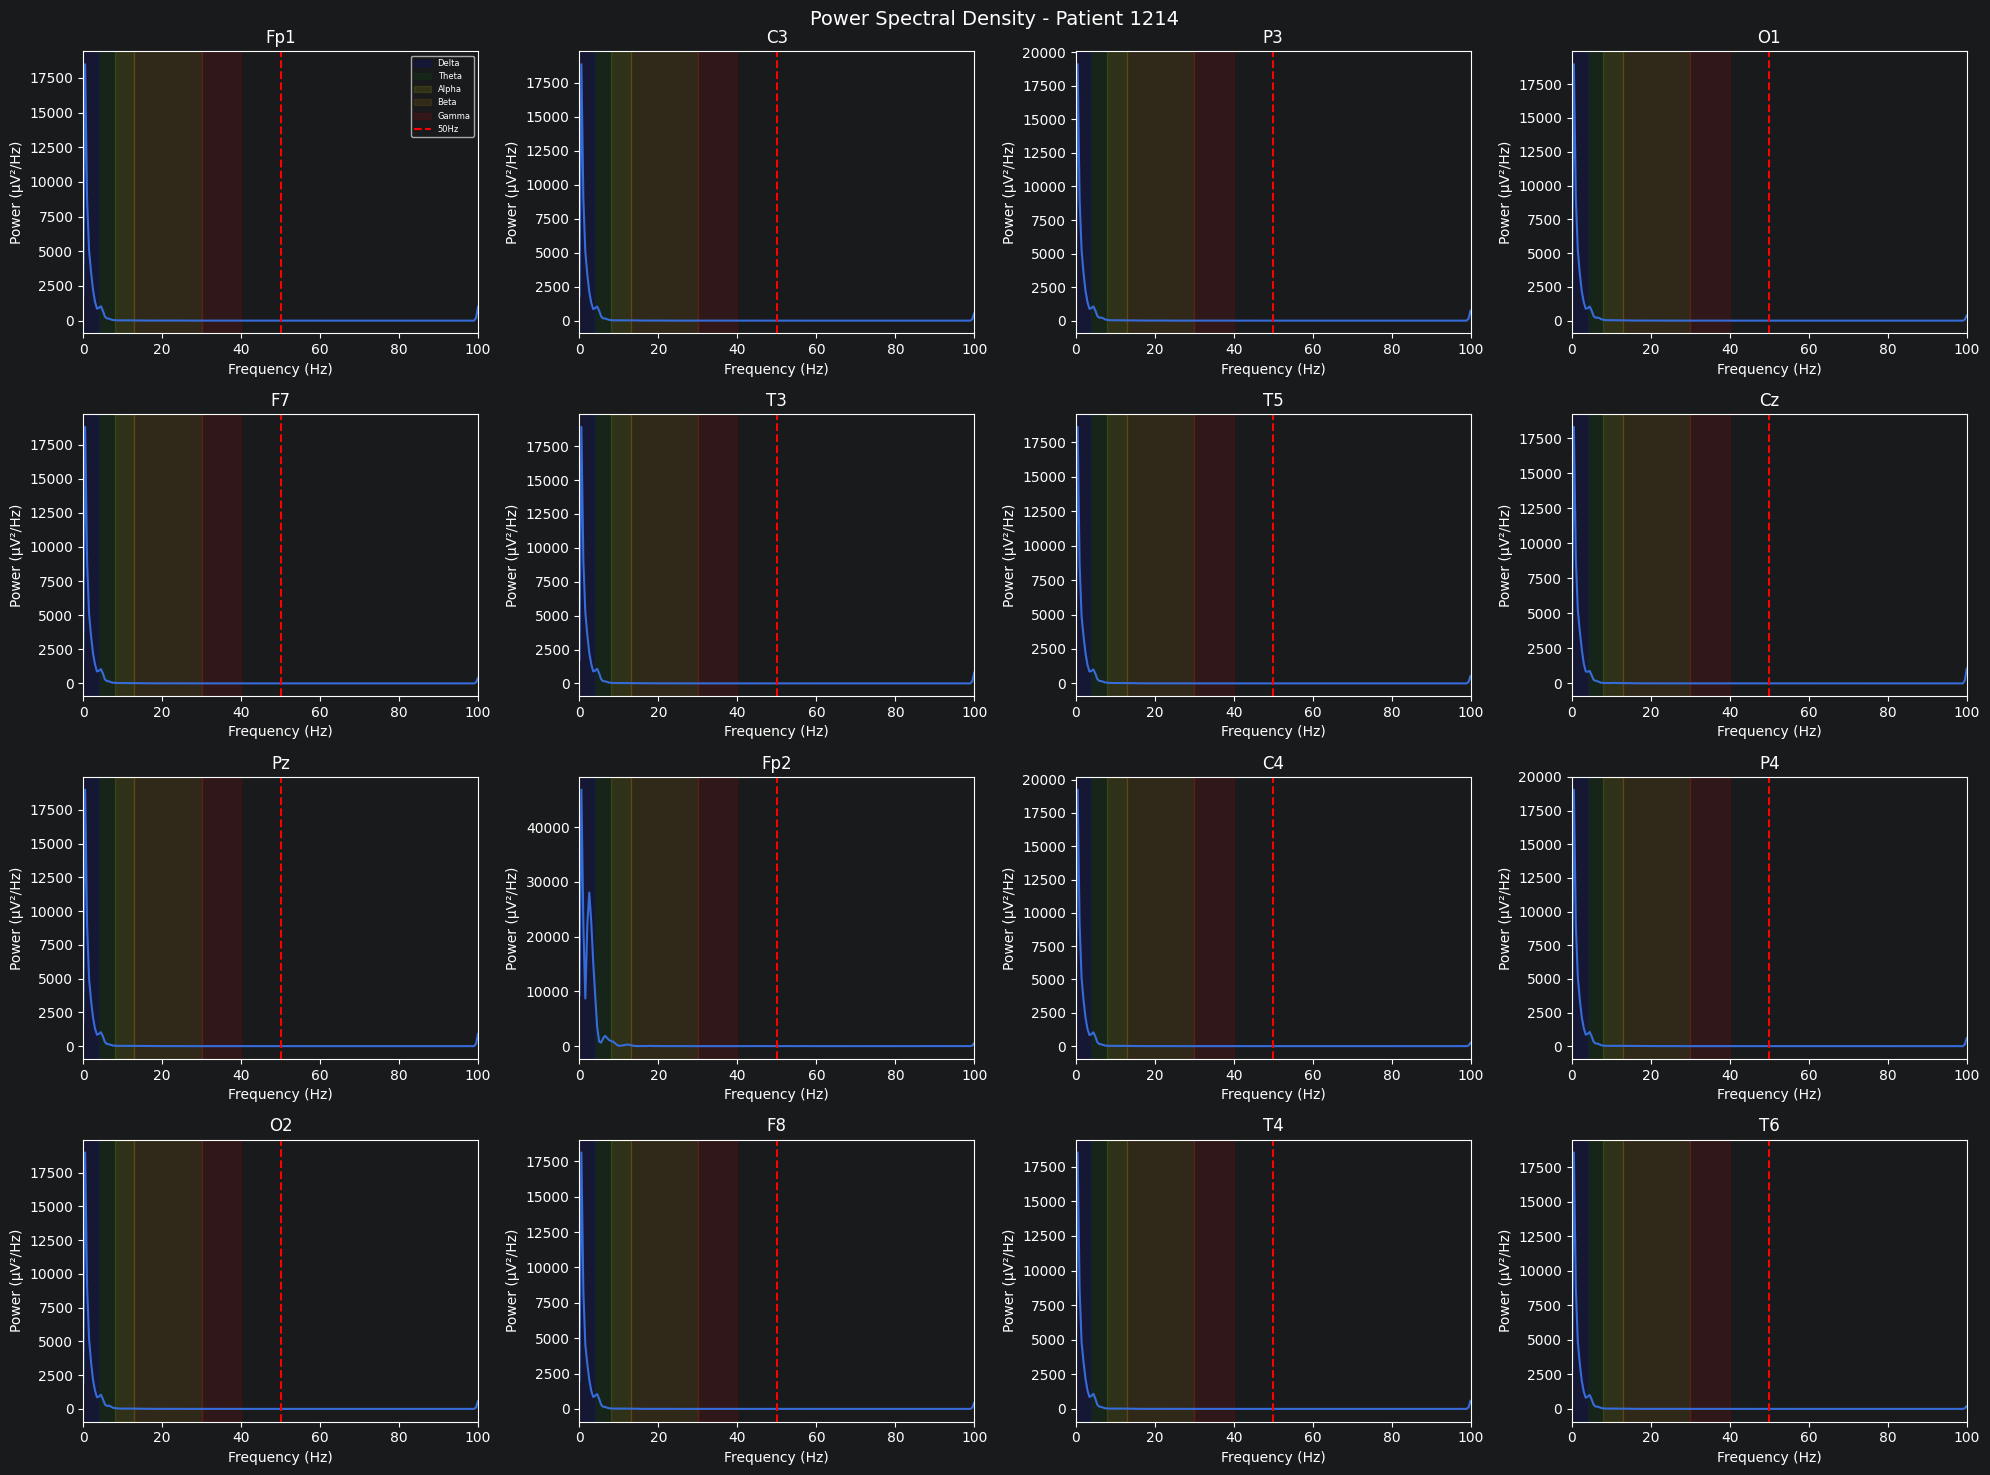

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Load one file
eeg_df = pd.read_csv(r'/eeg_csv/0/1214.csv')

ch_names = ['Fp1','C3','P3','O1','F7','T3','T5','Cz',
            'Pz','Fp2','C4','P4','O2','F8','T4','T6']

sfreq = 256

fig, axes = plt.subplots(4, 4, figsize=(20, 15))
axes = axes.flatten()

for i, ch in enumerate(ch_names):
    signal = eeg_df[ch].values

    # Compute PSD using Welch method
    freqs, psd = welch(signal, fs=sfreq, nperseg=sfreq*2)

    axes[i].plot(freqs, psd)
    axes[i].set_title(ch)
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('Power (µV²/Hz)')
    axes[i].set_xlim(0, 100)  # show up to 100 Hz

    # Mark frequency bands
    axes[i].axvspan(0.5,  4,  alpha=0.1, color='blue',   label='Delta')
    axes[i].axvspan(4,    8,  alpha=0.1, color='green',  label='Theta')
    axes[i].axvspan(8,   13,  alpha=0.1, color='yellow', label='Alpha')
    axes[i].axvspan(13,  30,  alpha=0.1, color='orange', label='Beta')
    axes[i].axvspan(30,  40,  alpha=0.1, color='red',    label='Gamma')
    axes[i].axvline(50,       color='red', linestyle='--', label='50Hz')

axes[0].legend(fontsize=6)
plt.suptitle('Power Spectral Density - Patient 1214', fontsize=14)
plt.tight_layout()
plt.show()

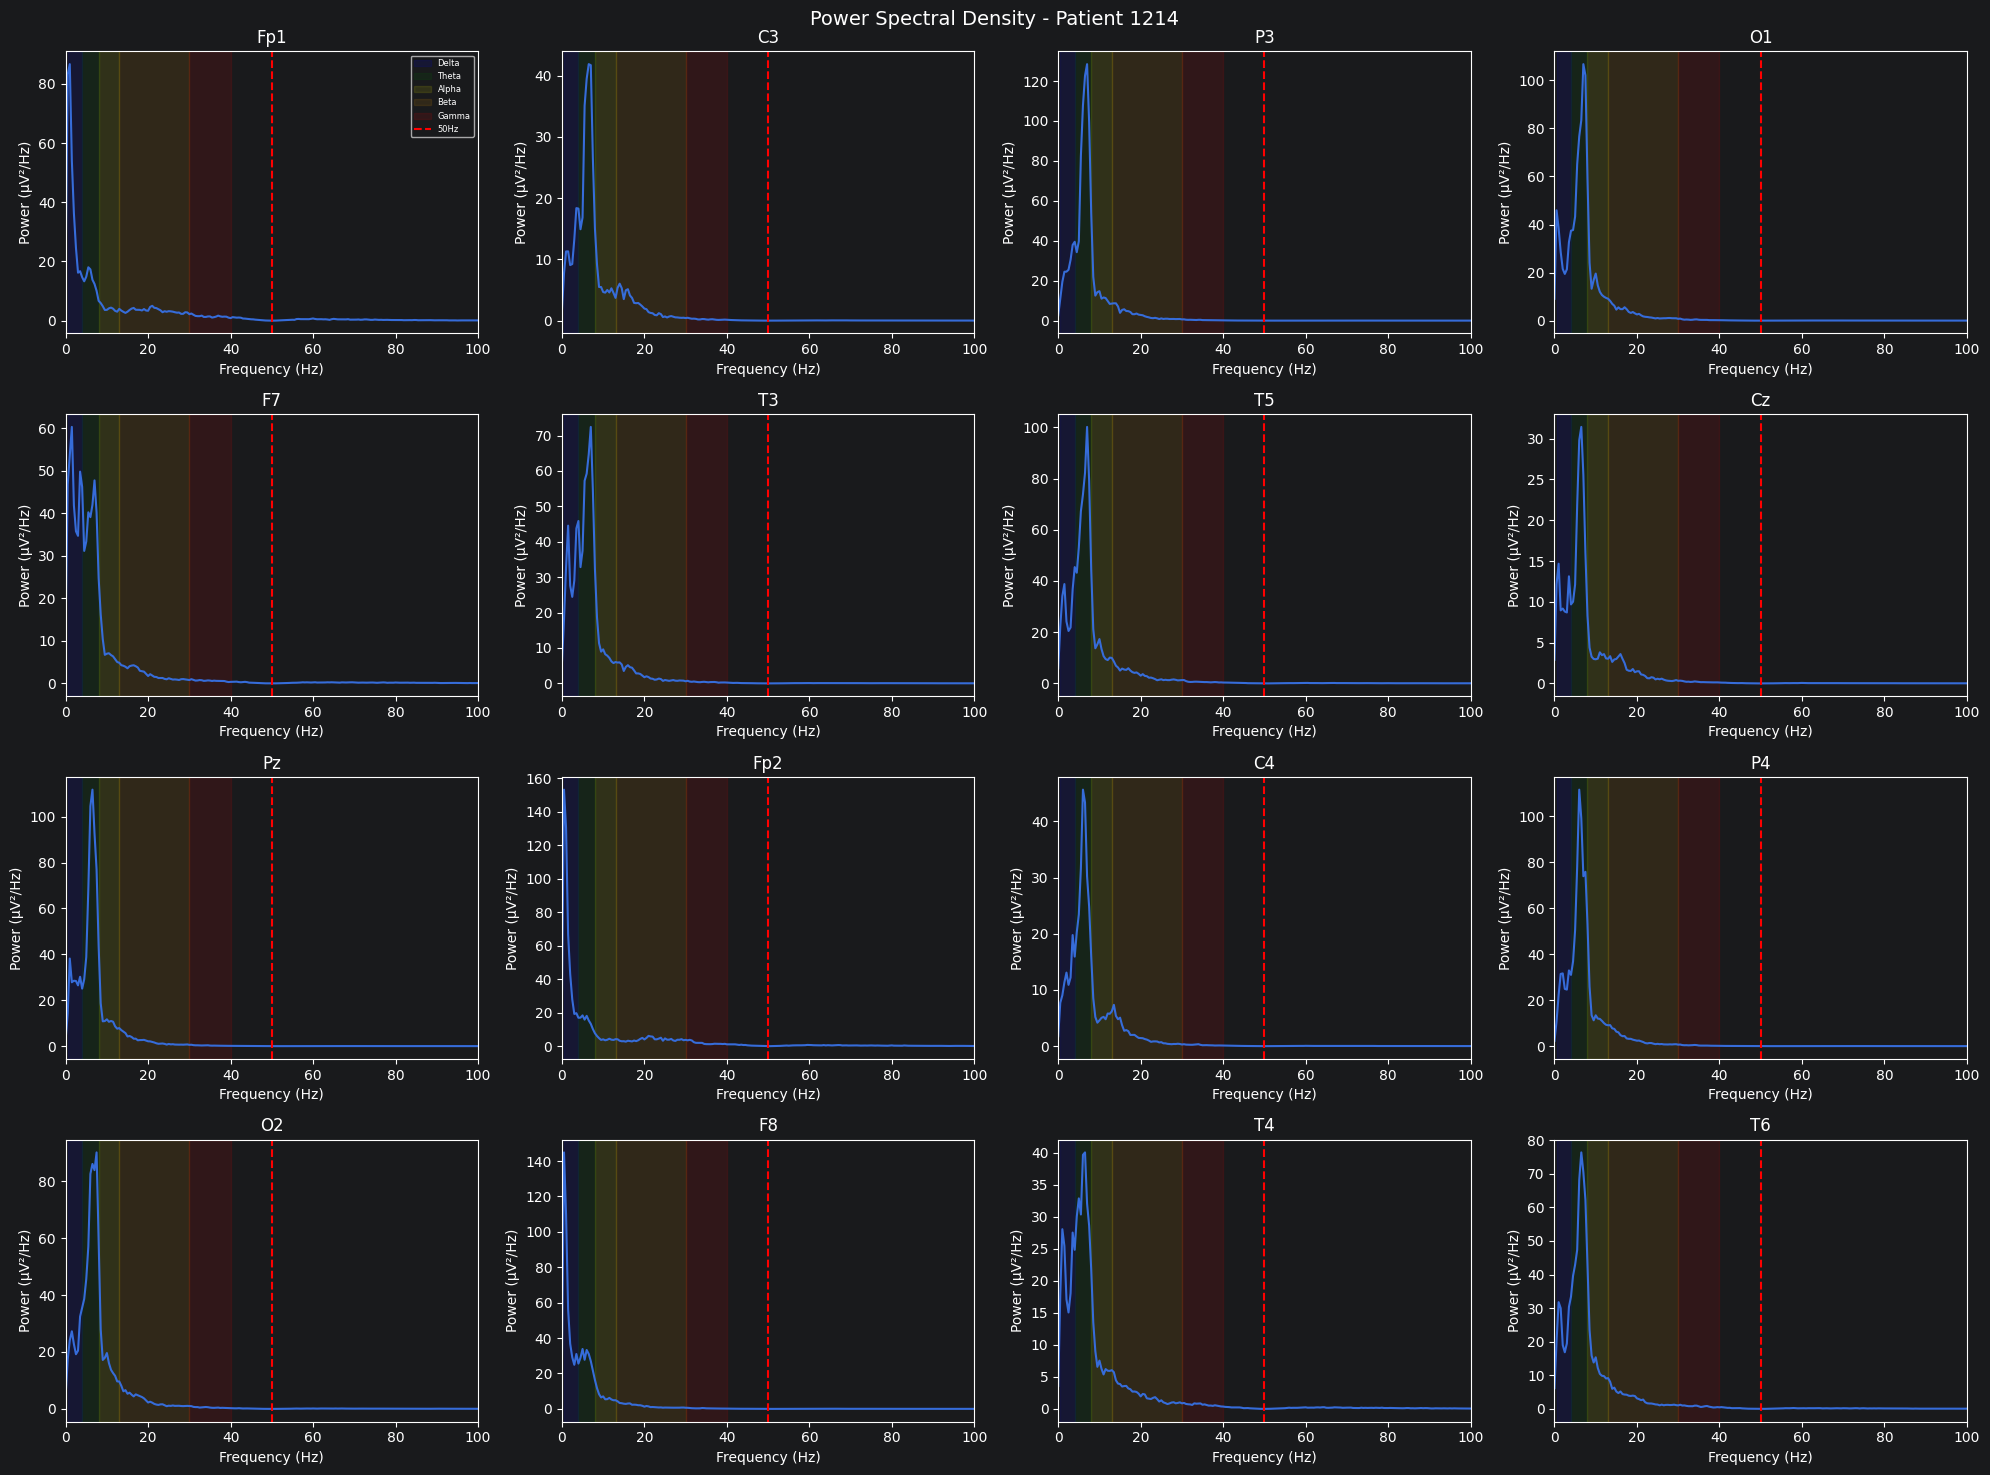

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

eeg_df = pd.read_csv(r'/eeg_csv/0/8324.csv')

ch_names = ['Fp1','C3','P3','O1','F7','T3','T5','Cz',
            'Pz','Fp2','C4','P4','O2','F8','T4','T6']

sfreq = 256

fig, axes = plt.subplots(4, 4, figsize=(20, 15))
axes = axes.flatten()

for i, ch in enumerate(ch_names):
    signal = eeg_df[ch].values

    freqs, psd = welch(signal, fs=sfreq, nperseg=sfreq*2)

    axes[i].plot(freqs, psd)
    axes[i].set_title(ch)
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('Power (µV²/Hz)')
    axes[i].set_xlim(0, 100)  # show up to 100 Hz

    # Mark frequency bands
    axes[i].axvspan(0.5,  4,  alpha=0.1, color='blue',   label='Delta')
    axes[i].axvspan(4,    8,  alpha=0.1, color='green',  label='Theta')
    axes[i].axvspan(8,   13,  alpha=0.1, color='yellow', label='Alpha')
    axes[i].axvspan(13,  30,  alpha=0.1, color='orange', label='Beta')
    axes[i].axvspan(30,  40,  alpha=0.1, color='red',    label='Gamma')
    axes[i].axvline(50,       color='red', linestyle='--', label='50Hz')

axes[0].legend(fontsize=6)
plt.suptitle('Power Spectral Density - Patient 1214', fontsize=14)
plt.tight_layout()
plt.show()

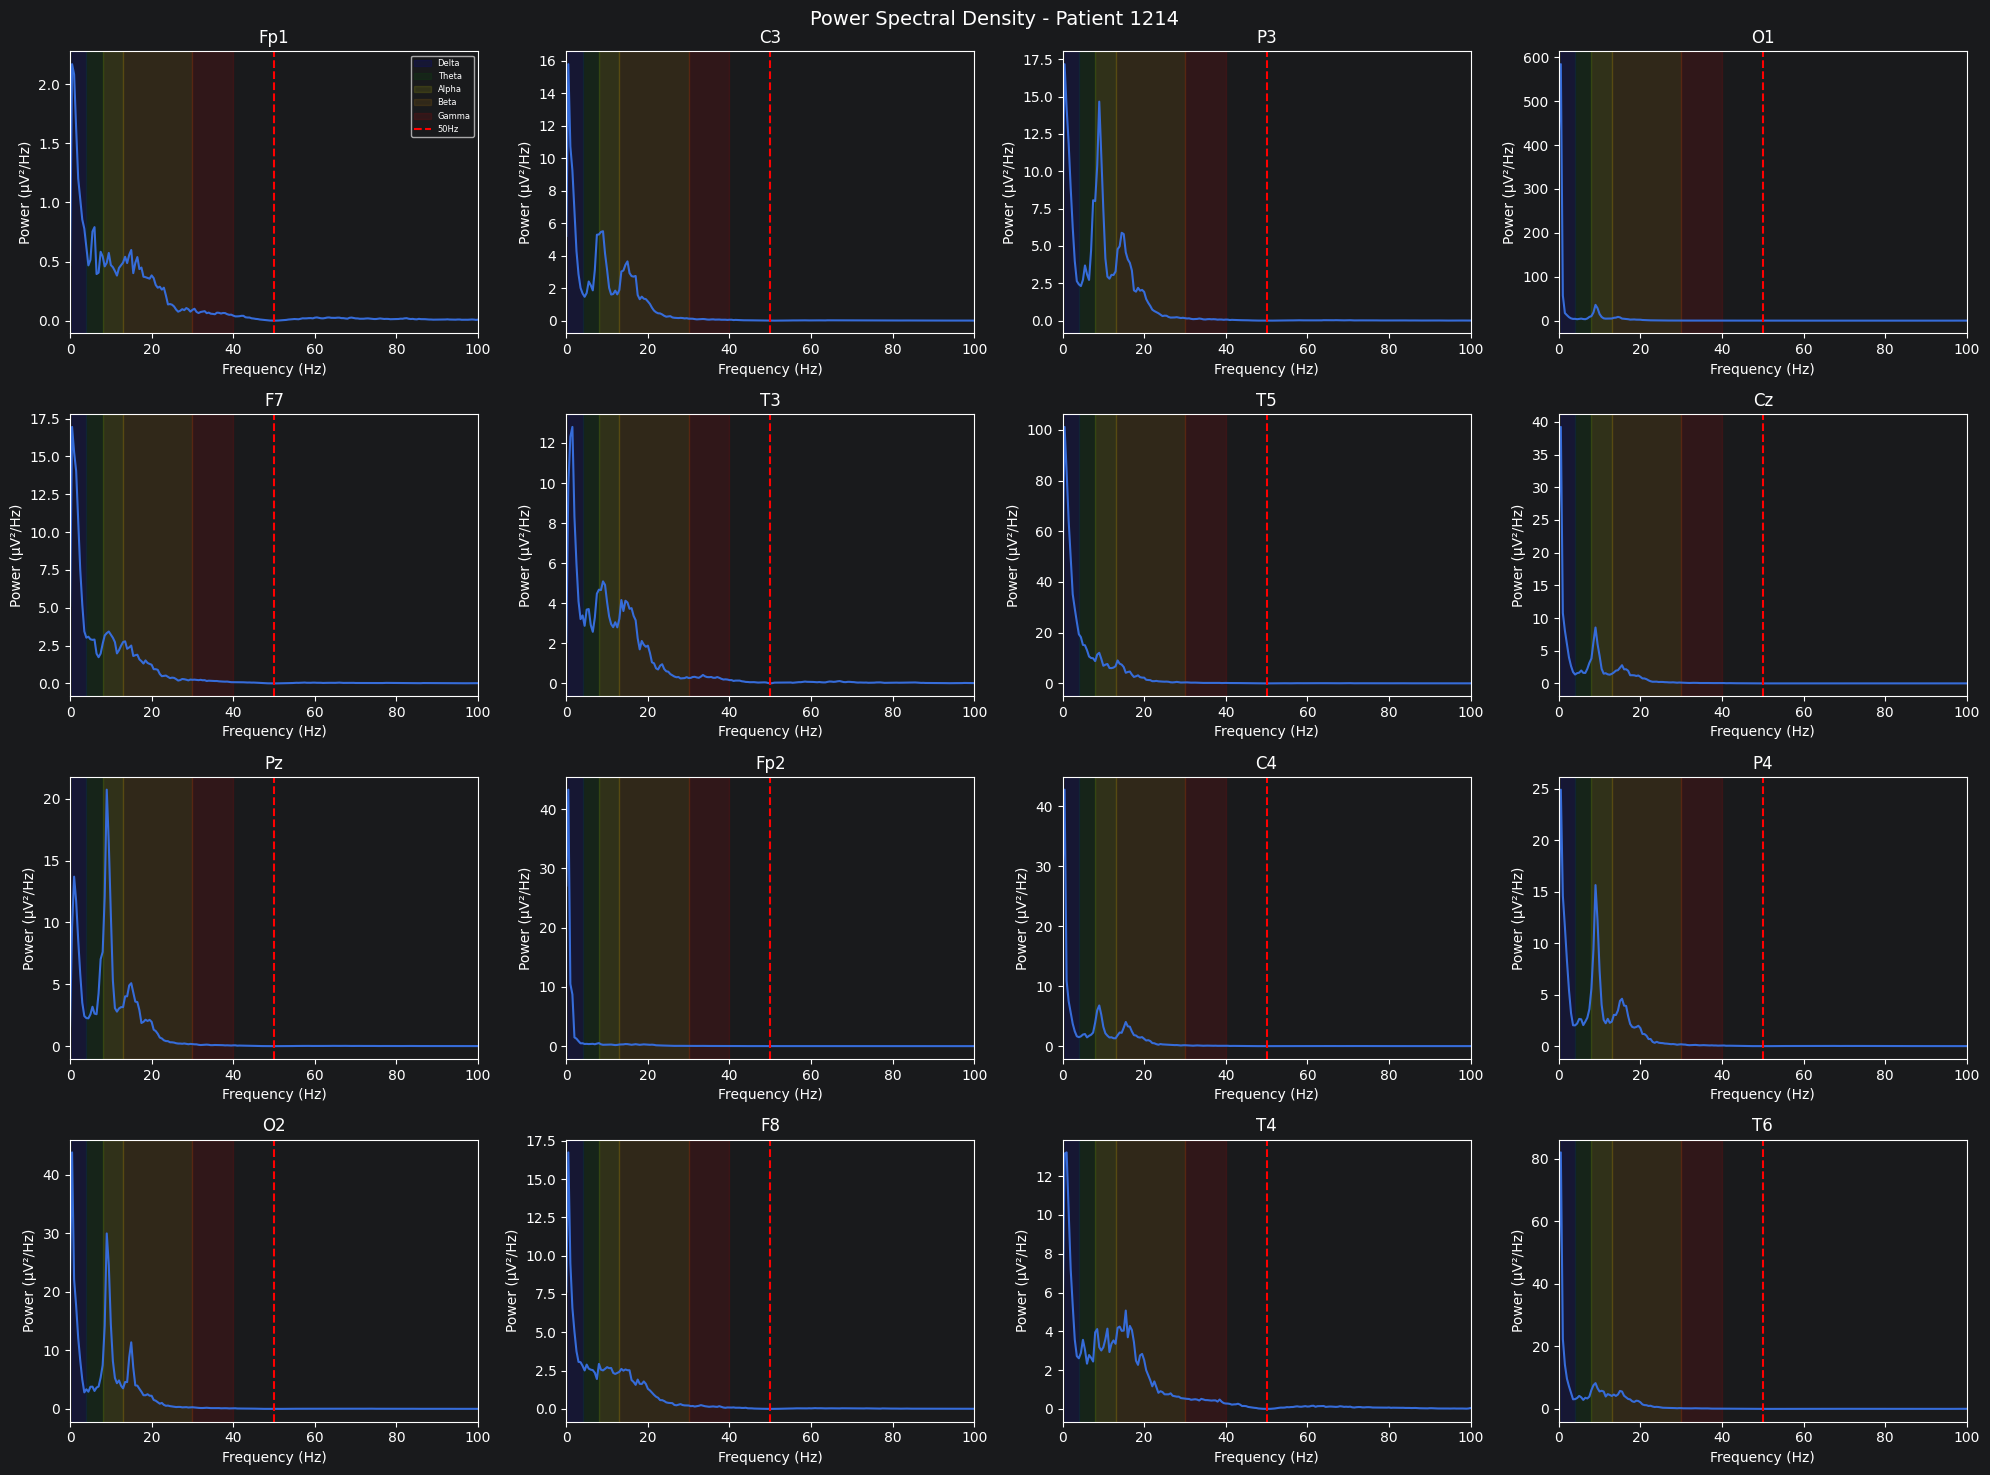

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

eeg_df = pd.read_csv(r'/eeg_csv/0/8858.csv')

ch_names = ['Fp1','C3','P3','O1','F7','T3','T5','Cz',
            'Pz','Fp2','C4','P4','O2','F8','T4','T6']

sfreq = 256

fig, axes = plt.subplots(4, 4, figsize=(20, 15))
axes = axes.flatten()

for i, ch in enumerate(ch_names):
    signal = eeg_df[ch].values

    freqs, psd = welch(signal, fs=sfreq, nperseg=sfreq*2)

    axes[i].plot(freqs, psd)
    axes[i].set_title(ch)
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('Power (µV²/Hz)')
    axes[i].set_xlim(0, 100)  # show up to 100 Hz

    # Mark frequency bands
    axes[i].axvspan(0.5,  4,  alpha=0.1, color='blue',   label='Delta')
    axes[i].axvspan(4,    8,  alpha=0.1, color='green',  label='Theta')
    axes[i].axvspan(8,   13,  alpha=0.1, color='yellow', label='Alpha')
    axes[i].axvspan(13,  30,  alpha=0.1, color='orange', label='Beta')
    axes[i].axvspan(30,  40,  alpha=0.1, color='red',    label='Gamma')
    axes[i].axvline(50,       color='red', linestyle='--', label='50Hz')

axes[0].legend(fontsize=6)
plt.suptitle('Power Spectral Density - Patient 1214', fontsize=14)
plt.tight_layout()
plt.show()

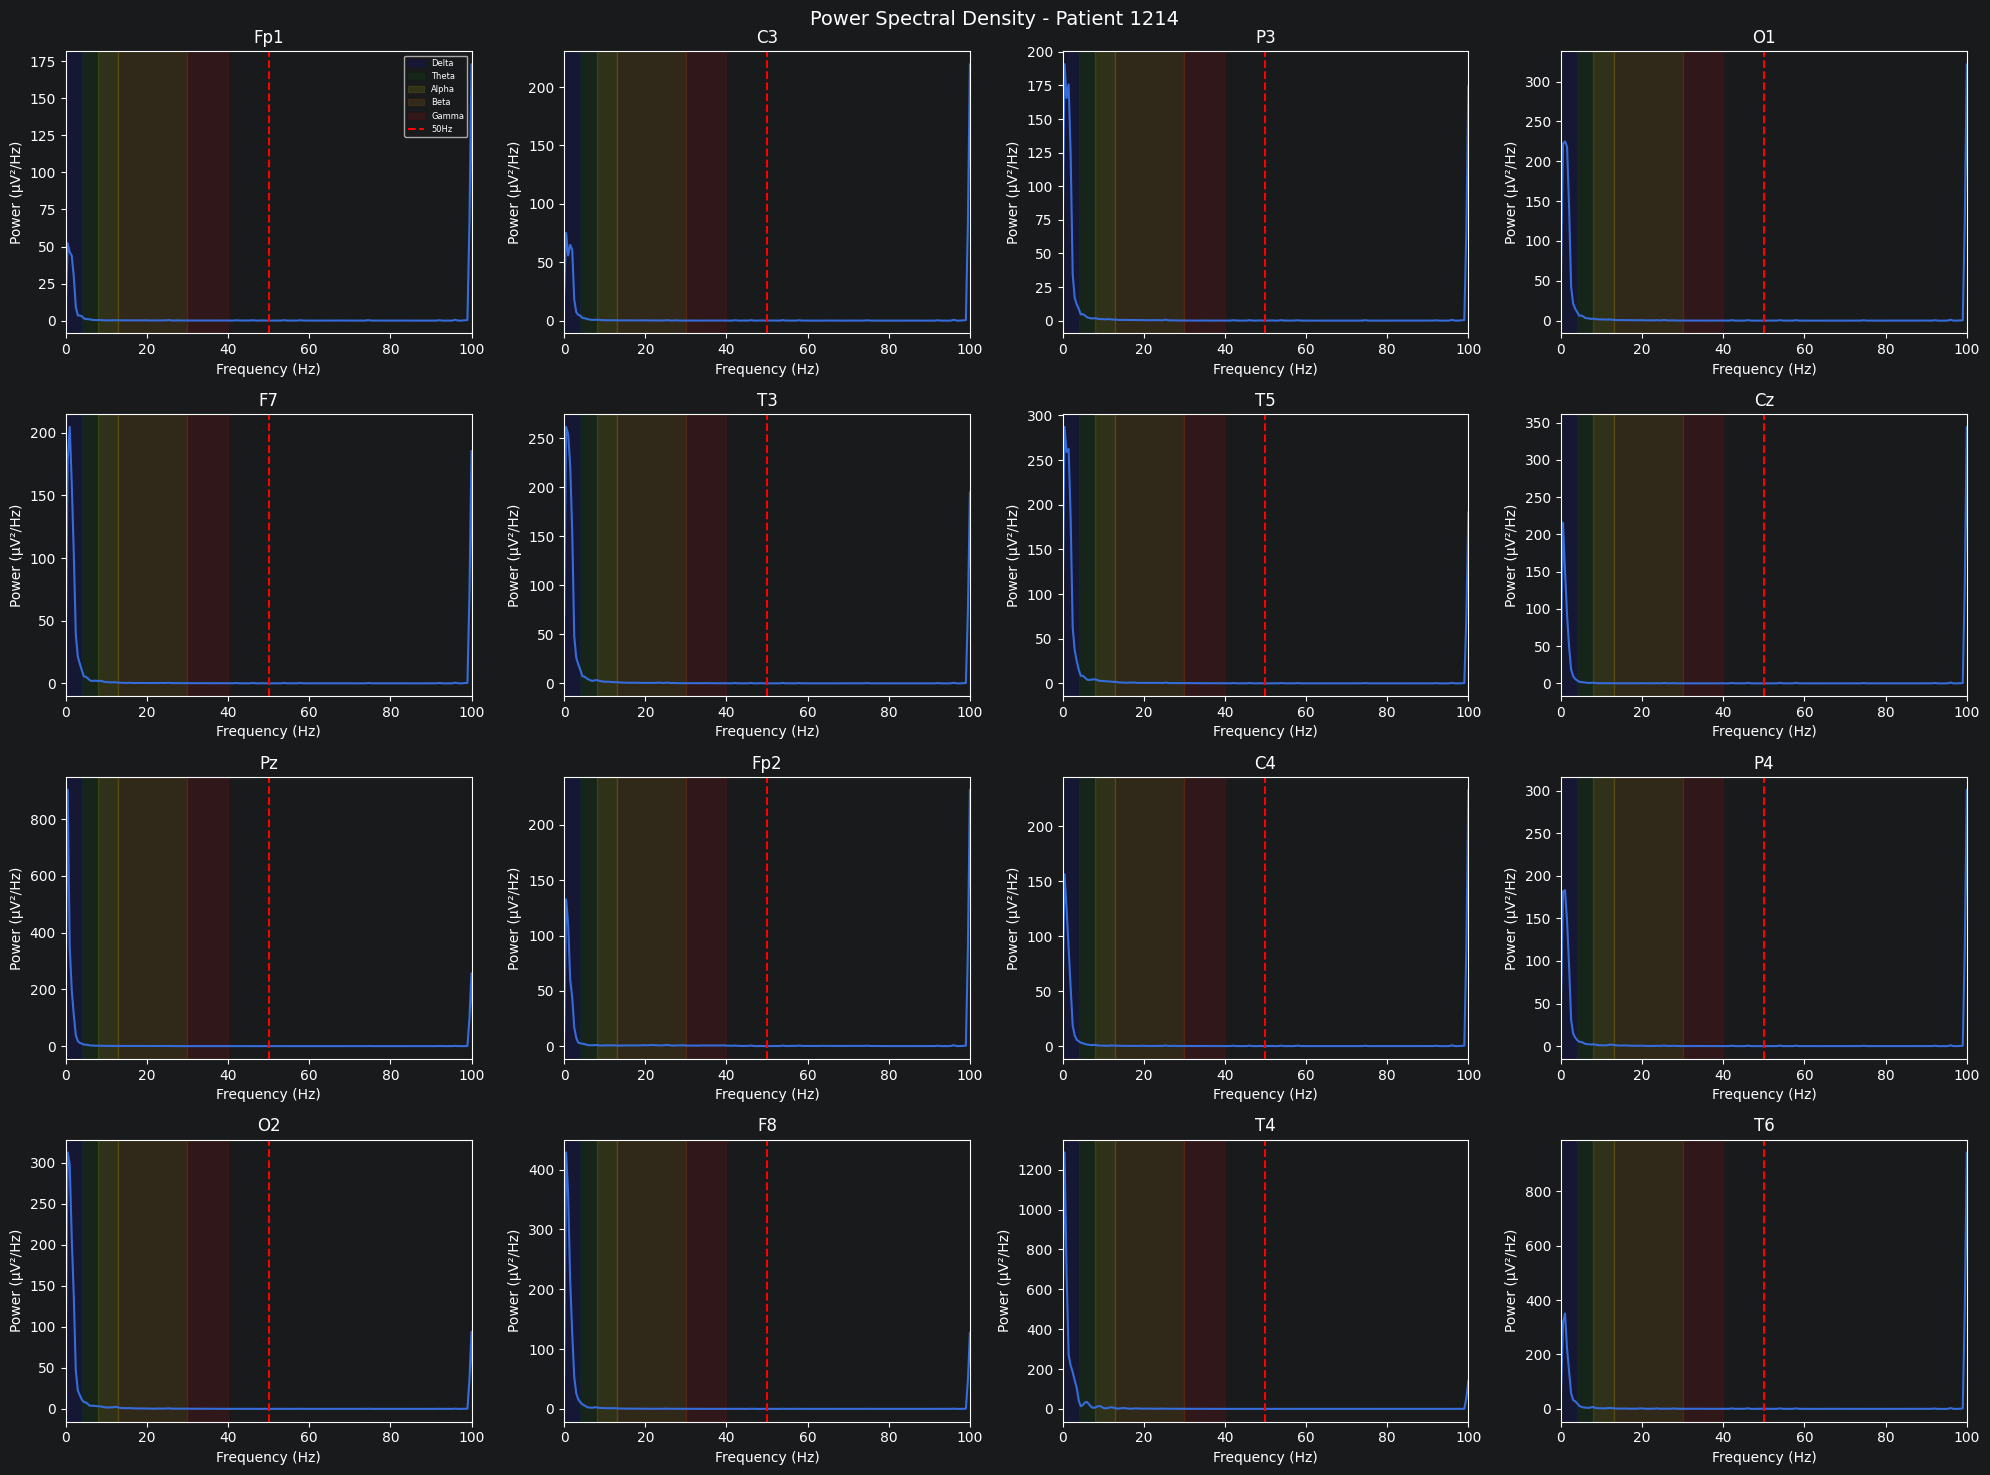

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

eeg_df = pd.read_csv(r'/eeg_csv/1/8250.csv')

ch_names = ['Fp1','C3','P3','O1','F7','T3','T5','Cz',
            'Pz','Fp2','C4','P4','O2','F8','T4','T6']

sfreq = 256

fig, axes = plt.subplots(4, 4, figsize=(20, 15))
axes = axes.flatten()

for i, ch in enumerate(ch_names):
    signal = eeg_df[ch].values

    freqs, psd = welch(signal, fs=sfreq, nperseg=sfreq*2)

    axes[i].plot(freqs, psd)
    axes[i].set_title(ch)
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('Power (µV²/Hz)')
    axes[i].set_xlim(0, 100)  # show up to 100 Hz

    # Mark frequency bands
    axes[i].axvspan(0.5,  4,  alpha=0.1, color='blue',   label='Delta')
    axes[i].axvspan(4,    8,  alpha=0.1, color='green',  label='Theta')
    axes[i].axvspan(8,   13,  alpha=0.1, color='yellow', label='Alpha')
    axes[i].axvspan(13,  30,  alpha=0.1, color='orange', label='Beta')
    axes[i].axvspan(30,  40,  alpha=0.1, color='red',    label='Gamma')
    axes[i].axvline(50,       color='red', linestyle='--', label='50Hz')

axes[0].legend(fontsize=6)
plt.suptitle('Power Spectral Density - Patient 1214', fontsize=14)
plt.tight_layout()
plt.show()

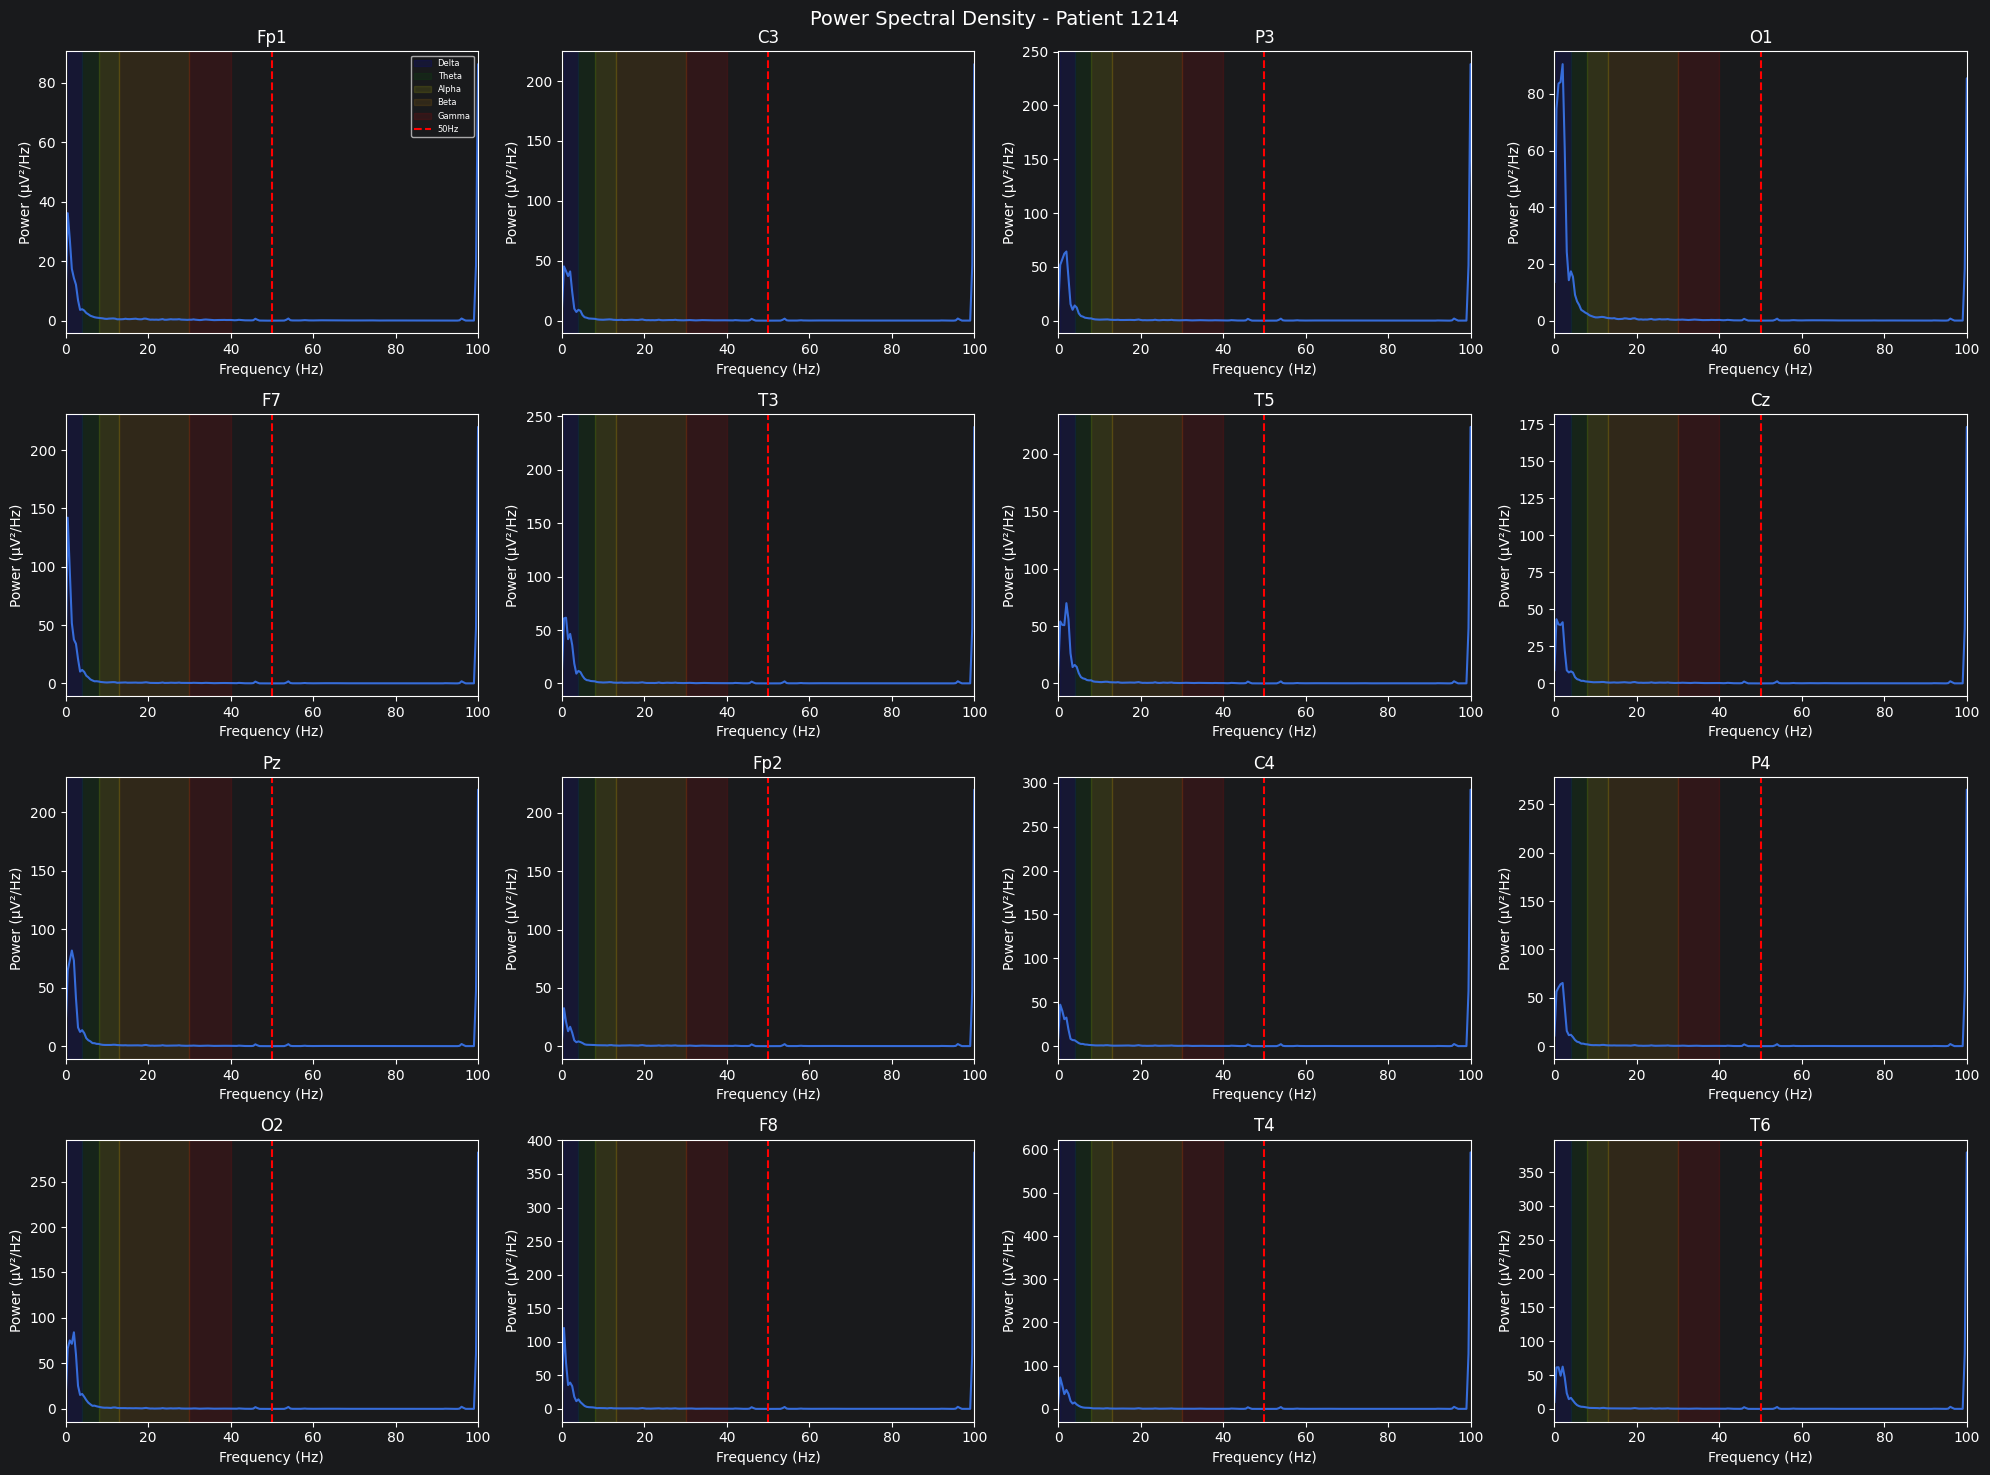

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

eeg_df = pd.read_csv(r'/eeg_csv/1/5160.csv')

ch_names = ['Fp1','C3','P3','O1','F7','T3','T5','Cz',
            'Pz','Fp2','C4','P4','O2','F8','T4','T6']

sfreq = 256

fig, axes = plt.subplots(4, 4, figsize=(20, 15))
axes = axes.flatten()

for i, ch in enumerate(ch_names):
    signal = eeg_df[ch].values

    freqs, psd = welch(signal, fs=sfreq, nperseg=sfreq*2)

    axes[i].plot(freqs, psd)
    axes[i].set_title(ch)
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('Power (µV²/Hz)')
    axes[i].set_xlim(0, 100)  # show up to 100 Hz

    # Mark frequency bands
    axes[i].axvspan(0.5,  4,  alpha=0.1, color='blue',   label='Delta')
    axes[i].axvspan(4,    8,  alpha=0.1, color='green',  label='Theta')
    axes[i].axvspan(8,   13,  alpha=0.1, color='yellow', label='Alpha')
    axes[i].axvspan(13,  30,  alpha=0.1, color='orange', label='Beta')
    axes[i].axvspan(30,  40,  alpha=0.1, color='red',    label='Gamma')
    axes[i].axvline(50,       color='red', linestyle='--', label='50Hz')

axes[0].legend(fontsize=6)
plt.suptitle('Power Spectral Density - Patient 1214', fontsize=14)
plt.tight_layout()
plt.show()

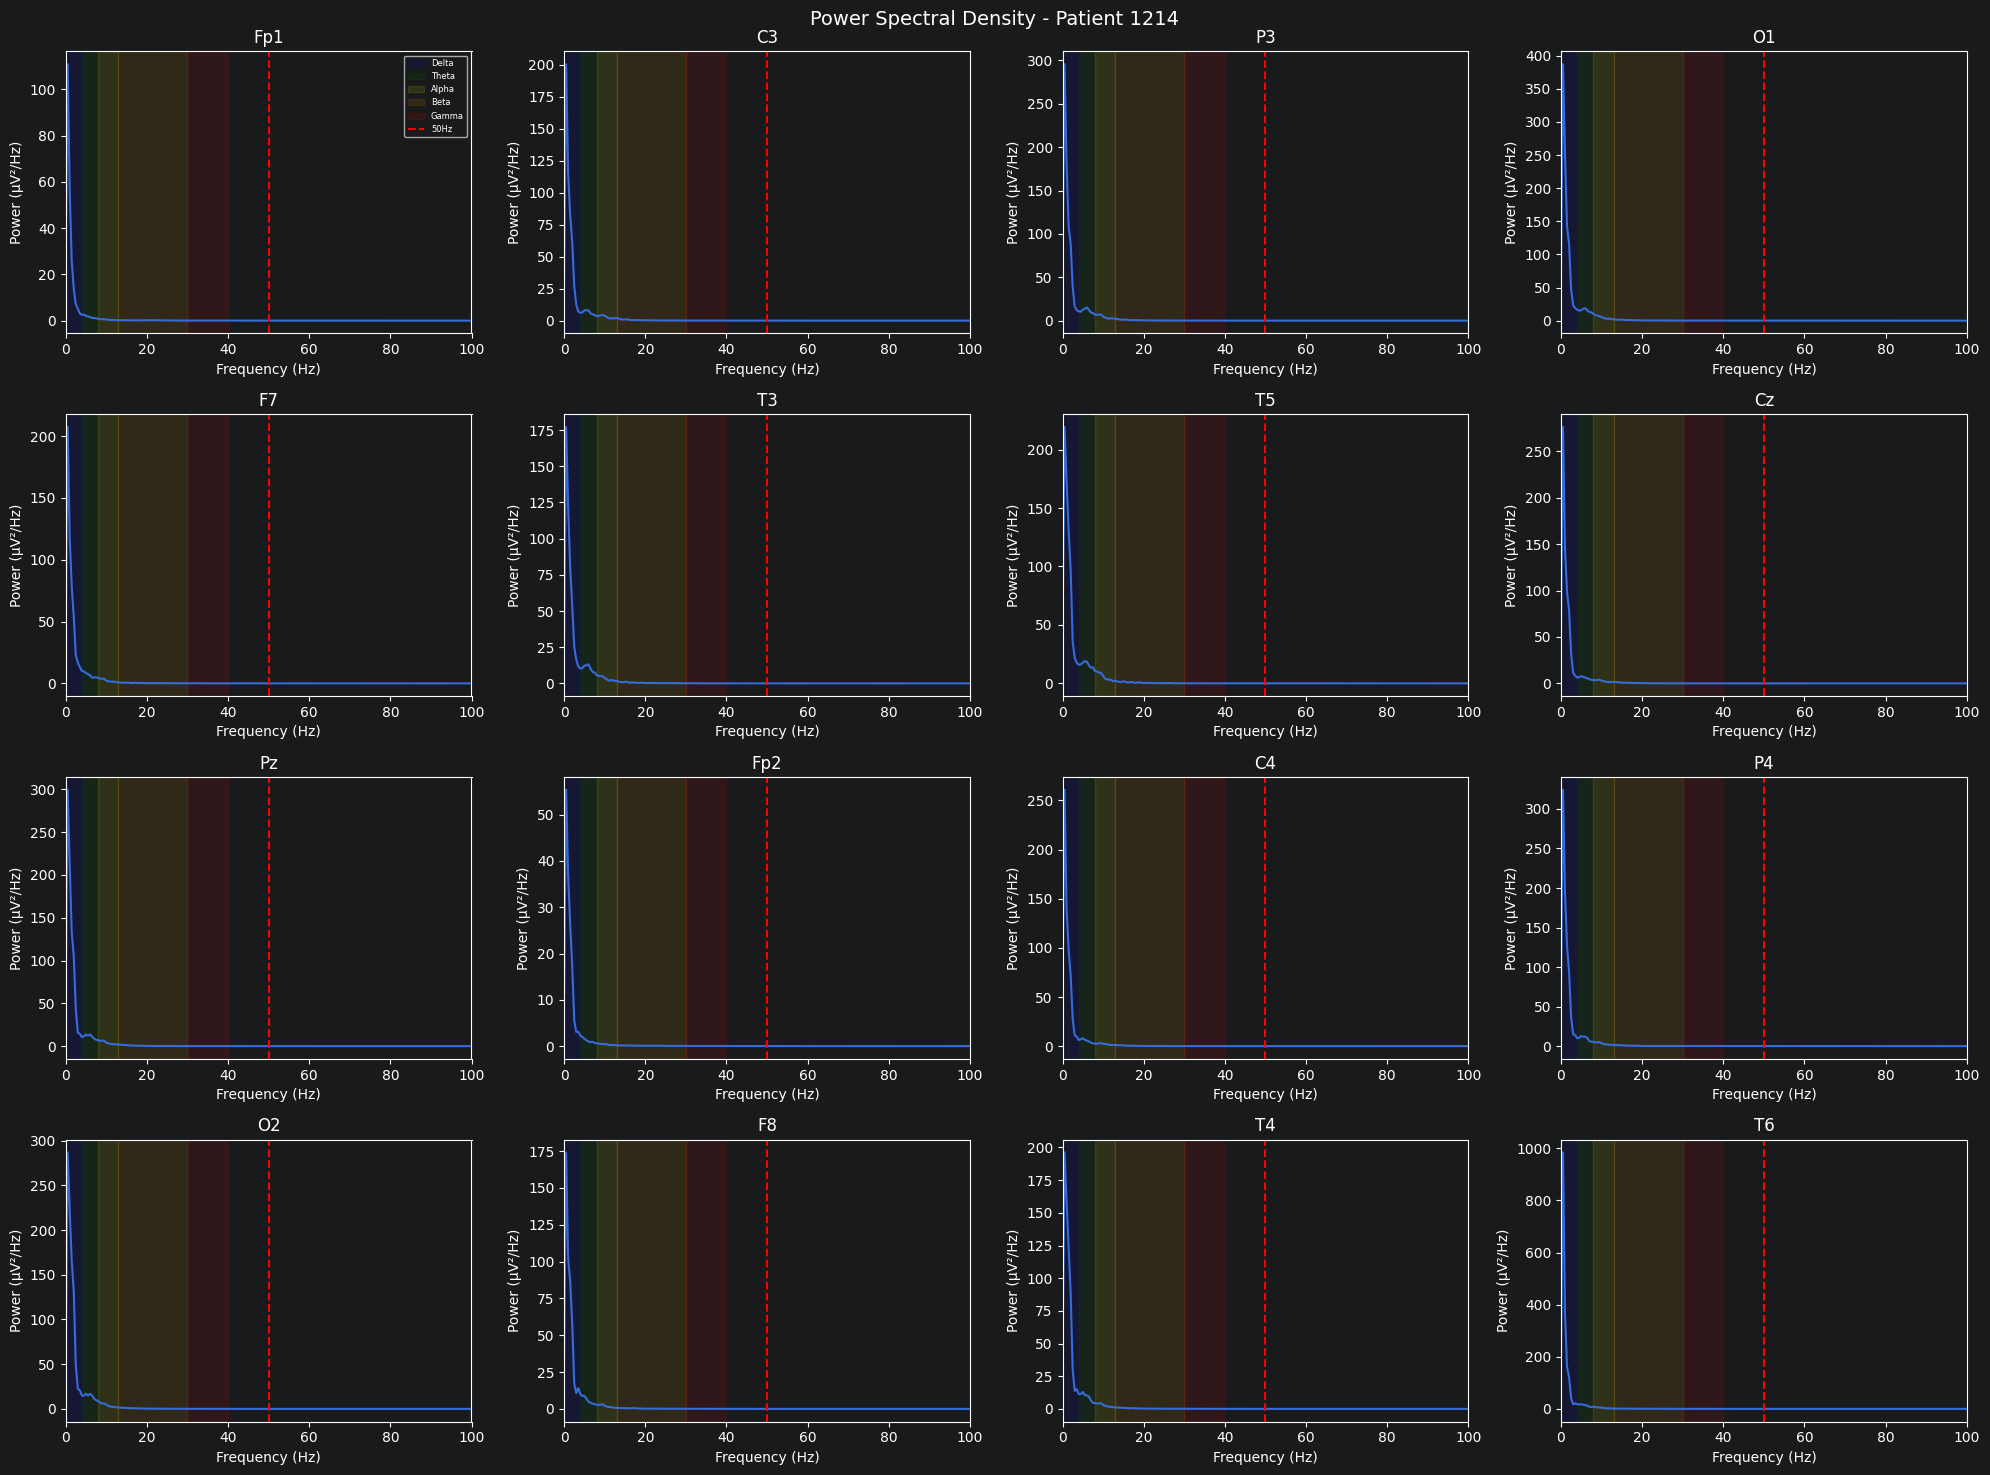

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

eeg_df = pd.read_csv(r'/eeg_csv/1/8280.csv')

ch_names = ['Fp1','C3','P3','O1','F7','T3','T5','Cz',
            'Pz','Fp2','C4','P4','O2','F8','T4','T6']

sfreq = 256

fig, axes = plt.subplots(4, 4, figsize=(20, 15))
axes = axes.flatten()

for i, ch in enumerate(ch_names):
    signal = eeg_df[ch].values

    freqs, psd = welch(signal, fs=sfreq, nperseg=sfreq*2)

    axes[i].plot(freqs, psd)
    axes[i].set_title(ch)
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('Power (µV²/Hz)')
    axes[i].set_xlim(0, 100)  # show up to 100 Hz

    # Mark frequency bands
    axes[i].axvspan(0.5,  4,  alpha=0.1, color='blue',   label='Delta')
    axes[i].axvspan(4,    8,  alpha=0.1, color='green',  label='Theta')
    axes[i].axvspan(8,   13,  alpha=0.1, color='yellow', label='Alpha')
    axes[i].axvspan(13,  30,  alpha=0.1, color='orange', label='Beta')
    axes[i].axvspan(30,  40,  alpha=0.1, color='red',    label='Gamma')
    axes[i].axvline(50,       color='red', linestyle='--', label='50Hz')

axes[0].legend(fontsize=6)
plt.suptitle('Power Spectral Density - Patient 1214', fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import os

folder_0 = r'C:\abalaji\bichat\eeg_csv\0'
folder_1 = r'C:\abalaji\bichat\eeg_csv\1'

ch_names = ['time','Fp1','C3','P3','O1','F7','T3','T5','Cz',
            'Pz','Fp2','C4','P4','O2','F8','T4','T6']

for folder in [folder_0, folder_1]:
    files = [f for f in os.listdir(folder) if f.endswith('.csv')]
    print(f"\nFolder: {folder} → {len(files)} files")

    for filename in files:
        filepath = os.path.join(folder, filename)

        df = pd.read_csv(filepath, usecols=ch_names)
        df.to_csv(filepath, index=False)  # overwrite same file

        print(f"✓ {filename} → shape {df.shape}")

print("\nDone!")


Folder: C:\abalaji\bichat\eeg_csv\0 → 70 files
✓ 1214.csv → shape (15360, 17)
✓ 8058.csv → shape (15360, 17)
✓ 8063.csv → shape (15360, 17)
✓ 8067.csv → shape (15360, 17)
✓ 8097.csv → shape (15360, 17)
✓ 8098.csv → shape (15360, 17)
✓ 8099.csv → shape (15360, 17)
✓ 8101.csv → shape (15360, 17)
✓ 8102.csv → shape (15360, 17)
✓ 8112.csv → shape (15360, 17)
✓ 8113.csv → shape (15360, 17)
✓ 8127.csv → shape (15360, 17)
✓ 8132.csv → shape (15360, 17)
✓ 8133.csv → shape (15360, 17)
✓ 8153.csv → shape (15360, 17)
✓ 8157.csv → shape (15360, 17)
✓ 8158.csv → shape (15360, 17)
✓ 8159.csv → shape (15360, 17)
✓ 8165.csv → shape (15360, 17)
✓ 8166.csv → shape (15360, 17)
✓ 8173.csv → shape (15360, 17)
✓ 8193.csv → shape (15360, 17)
✓ 8201.csv → shape (15360, 17)
✓ 8210.csv → shape (15360, 17)
✓ 8213.csv → shape (15360, 17)
✓ 8243.csv → shape (15360, 17)
✓ 8251.csv → shape (15360, 17)
✓ 8254.csv → shape (15360, 17)
✓ 8257.csv → shape (15360, 17)
✓ 8263.csv → shape (15360, 17)
✓ 8264.csv → shape (15

Total patients: 97
Day-28 deaths: 26
Overall CFR: 26.8%


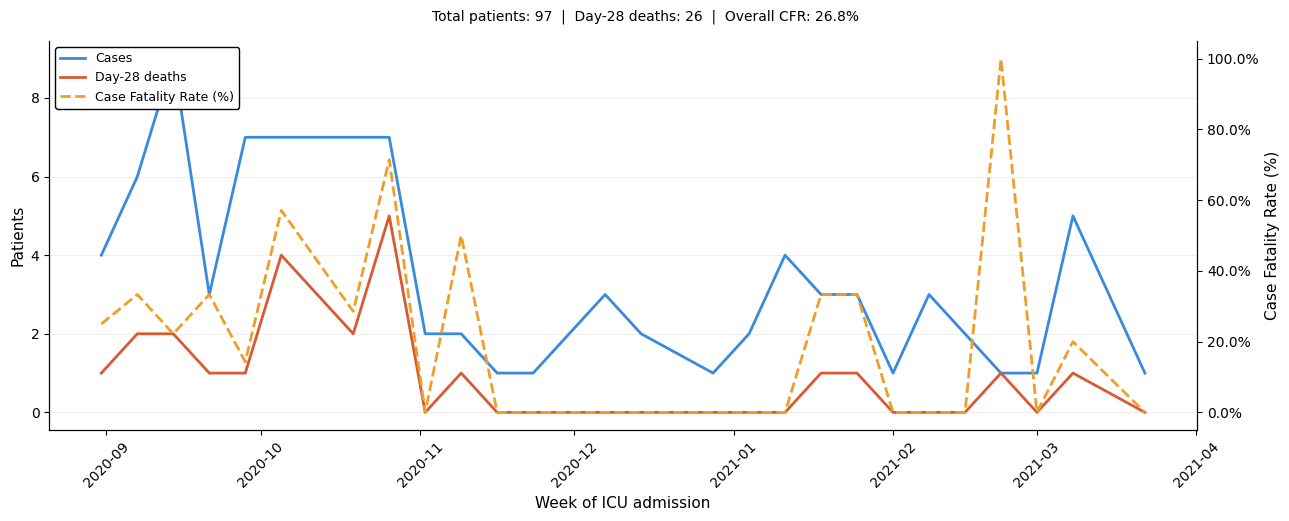

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'savefig.facecolor': 'white',
    'savefig.edgecolor': 'white'
})

valid_ids = df_clean['N_PAT'].unique()

df = df_base[
    ['N_PAT', 'Date admission réa', 'Mortalité J28']
].copy()

df = df[
    df['N_PAT'].isin(valid_ids) &
    ~df['N_PAT'].isin([5939, 8347, 8541])
]

df = df.dropna(
    subset=['Date admission réa', 'N_PAT', 'Mortalité J28']
).copy()

df['Date admission réa'] = pd.to_datetime(df['Date admission réa'])

total_patients = len(df)
total_deaths = int(df['Mortalité J28'].sum())
global_cfr = total_deaths / total_patients * 100

print(f"Total patients: {total_patients}")
print(f"Day-28 deaths: {total_deaths}")
print(f"Overall CFR: {global_cfr:.1f}%")

df['week'] = df['Date admission réa'].dt.to_period('W').dt.start_time

weekly = df.groupby('week').agg(
    cases=('N_PAT', 'count'),
    deaths=('Mortalité J28', 'sum')
).reset_index()

weekly['cfr_raw'] = (
    weekly['deaths'] /
    weekly['cases'].replace(0, pd.NA)
) * 100

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.plot(
    weekly['week'],
    weekly['cases'],
    color='#378ADD',
    linewidth=2,
    label='Cases'
)

ax1.plot(
    weekly['week'],
    weekly['deaths'],
    color='#D85A30',
    linewidth=2,
    label='Day-28 deaths'
)

ax2.plot(
    weekly['week'],
    weekly['cfr_raw'],
    color='#EF9F27',
    linewidth=2,
    linestyle='--',
    label='Case Fatality Rate (%)'
)

ax1.set_ylabel('Patients', fontsize=11)
ax1.set_xlabel('Week of ICU admission', fontsize=11)

ax2.set_ylabel('Case Fatality Rate (%)', fontsize=11, color='black')
ax2.tick_params(axis='y', colors='black')
ax2.yaxis.set_major_formatter(
    mticker.FormatStrFormatter('%.1f%%')
)

ax1.tick_params(axis='x', rotation=45)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.grid(True, axis='y', alpha=0.3)

summary = (
    f"Total patients: {total_patients}  |  "
    f"Day-28 deaths: {total_deaths}  |  "
    f"Overall CFR: {global_cfr:.1f}%"
)

fig.text(
    0.5,
    1.01,
    summary,
    ha='center',
    fontsize=10,
    color='black'
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left',
    fontsize=9,
    framealpha=1,
    facecolor='white',
    edgecolor='black'
)

plt.tight_layout()

plt.savefig(
    'cases_deaths_cfr_raw.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.savefig(
    'cases_deaths_cfr_raw.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()